# Road Context and Severity Corridors in Greater London Casualties


<style>
pre, code, .jp-CodeCell pre, .jp-InputArea-editor pre {
  white-space: pre-wrap !important;
  overflow-wrap: anywhere !important;
  word-break: break-word !important;
}
.jp-Cell-inputWrapper, .highlight, div.input_area {
  overflow-x: visible !important;
}
.jp-RenderedMarkdown img, .rendered_html img {
  max-width: 100% !important;
  height: auto !important;
  display: block;
  margin: 0 auto;
}
</style>


## Preparation

- Github link: https://github.com/jameslemon2002/CASA006-DSSS

- Dataset access: cached local files are used when present; otherwise the submitted GitHub repository is used as the first remote source, with official open-data URLs retained as fallbacks where available

- Number of words: approximately 1,480, excluding preparation notes, table of contents, code, tables, figures, and references

- Runtime: designed to run within several hours as required by the brief; cached local/GitHub data avoid the slowest first-time OSM retrieval step

- Coding environment: Python 3.12 on Windows

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library:
    - **GeoPandas**: spatial processing, nearest-road assignment, and projected mapping.
    - **OSMnx**: optional first-time retrieval of OpenStreetMap road links.
    - **scikit-learn**: logistic regression, tree-based classifiers, cross-validation, and model diagnostics.


## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)


<div style="page-break-before: always;"></div>

## Introduction

[[ go back to the top ]](#Table-of-contents)

London's Vision Zero agenda makes severe road injury a spatial planning problem, not only a transport-counting problem. Safe-system policy treats severe injury as a preventable system failure rather than only an individual road-user error (Belin et al., 2012). Casualty totals identify where collisions are reported, but they do not show whether severity is concentrated in particular road environments or along particular corridors. Road-safety research has long treated exposure as central: traffic volumes influence crash counts, while volume estimates themselves carry uncertainty (Høye and Hesjevoll, 2020; Musunuru and Porter, 2019). London evidence also links street morphology with pedestrian injury risk (Sarkar et al., 2018). Spatial hotspot studies argue that road collisions should be analysed in network space rather than only as planar points or administrative areas (Xie and Yan, 2008; Bíl et al., 2013).

Severe injury is therefore treated as a context-dependent and spatially uneven outcome. The analysis first tests whether the KSI gap between vulnerable users and car/taxi occupants changes across road environments, then uses model-adjusted residuals to identify LSOAs and corridors where observed severity remains higher than expected. The interpretation remains associative because STATS19 records reported casualties rather than complete walking, cycling, and traffic exposure.


## Research questions

[[ go back to the top ]](#Table-of-contents)

**Main research question.** How does the adjusted KSI probability gap between vulnerable road users and car/taxi occupants vary across road contexts, and which Greater London corridors show higher-than-expected KSI among reported casualties after model adjustment?

**Sub-question 1.** Does the vulnerable-road-user severity gap change across speed and lighting conditions?

**Sub-question 2.** After controlling for casualty, collision, vehicle, temporal, traffic-flow, and neighbourhood context, where do residual KSI outcomes remain higher than expected?

KSI means killed or seriously injured. Vulnerable road users are pedestrians, cyclists, and motorcyclists; car/taxi occupants form the reference group. "Higher than expected" means observed KSI casualties exceed fitted probabilities among reported casualties.


## Data

[[ go back to the top ]](#Table-of-contents)

The main data are 2024 Department for Transport STATS19 collision, casualty, and vehicle tables. Greater London collisions are selected using local authority ONS codes beginning `E09`, giving 20,967 collisions and 23,997 casualty records. The outcome is a binary KSI indicator: 3,704 casualties, or 15.4% of records, were killed or seriously injured. DfT/GLA 2024 borough traffic-flow estimates provide vehicle-kilometres for exposure context, while GLA borough and ONS LSOA boundaries support mapping.

Collision points are projected to British National Grid and assigned to the nearest OpenStreetMap drivable road link within 35 metres. The assignment covers 99.4% of London collision points, with a median snap distance of 1.9 metres and a 95th percentile of 14.7 metres. Unknown STATS19 codes are retained as explicit `Unknown` categories, and identifiers, raw coordinates, and vehicle make text are excluded from modelling. IMD 2019 is used as neighbourhood context rather than proof of causal deprivation effects.


In [1]:
from pathlib import Path
import json
import urllib.request
import warnings

import geopandas as gpd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)

DATA_DIR = Path("pilot_data")
GITHUB_REPO = "https://github.com/jameslemon2002/CASA006-DSSS"
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/jameslemon2002/CASA006-DSSS/main/"
COLLISION_URL = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2024.csv"
CASUALTY_URL = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2024.csv"
VEHICLE_URL = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-2024.csv"
BOROUGH_URL = "https://data.london.gov.uk/download/e55pw/9502cdec-5df0-46e3-8aa1-2b5c5233a31f/London_Boroughs.gpkg"
TRAFFIC_URL = "https://data.london.gov.uk/download/v8pow/87e880c2-34bd-4d86-8895-e8c5344f358e/traffic-flow-borough.xlsx"
OSM_EDGES = DATA_DIR / "osm_london_drive_edges.gpkg"
LSOA_BOUNDARIES = DATA_DIR / "london_lsoa_2011_boundaries.geojson"


def github_raw(path):
    return GITHUB_RAW_BASE + str(path).replace("\\", "/").lstrip("/")


def ensure_file(path, github_path=None, fallback_url=None):
    target = Path(path)
    if target.exists():
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = []
    if github_path is not None:
        urls.append(github_path if str(github_path).startswith("http") else github_raw(github_path))
    if fallback_url is not None:
        urls.append(fallback_url)
    errors = []
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=240) as response:
                target.write_bytes(response.read())
            return target
        except Exception as exc:
            errors.append(f"{url}: {exc}")
    raise FileNotFoundError(f"Could not retrieve {target}. Tried: {'; '.join(errors)}")


def local_or_url(filename, url=None):
    return ensure_file(DATA_DIR / filename, f"pilot_data/{filename}", url)


def add_map_elements(ax, bounds, scale_length=10000):
    minx, miny, maxx, maxy = bounds
    width, height = maxx - minx, maxy - miny
    sx, sy = minx + 0.06 * width, miny + 0.08 * height
    ax.plot([sx, sx + scale_length], [sy, sy], color="#222222", lw=2.2)
    ax.text(sx + scale_length / 2, sy + 0.018 * height, f"{int(scale_length/1000)} km", ha="center", fontsize=8)
    nx, ny = maxx - 0.08 * width, maxy - 0.12 * height
    ax.annotate("N", xy=(nx, ny + 0.07 * height), xytext=(nx, ny), arrowprops=dict(arrowstyle="-|>", lw=1.6), ha="center", fontsize=10, fontweight="bold")


def ensure_lsoa_boundaries(lsoa_codes):
    if LSOA_BOUNDARIES.exists():
        return LSOA_BOUNDARIES
    try:
        return local_or_url("london_lsoa_2011_boundaries.geojson")
    except Exception:
        pass

    import urllib.parse

    service_url = (
        "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
        "LSOA_Dec_2011_Boundaries_Generalised_Clipped_BGC_EW_V3/FeatureServer/0/query"
    )
    features = []
    codes = sorted({str(code) for code in lsoa_codes if pd.notna(code)})
    for start in range(0, len(codes), 400):
        chunk = codes[start:start + 400]
        where = "LSOA11CD IN (" + ",".join(f"'{code}'" for code in chunk) + ")"
        params = {
            "where": where,
            "outFields": "LSOA11CD,LSOA11NM",
            "returnGeometry": "true",
            "outSR": "4326",
            "f": "geojson",
        }
        request = urllib.request.Request(service_url, data=urllib.parse.urlencode(params).encode("utf-8"), method="POST")
        with urllib.request.urlopen(request, timeout=90) as response:
            payload = json.loads(response.read().decode("utf-8"))
        if "error" in payload:
            raise RuntimeError(payload["error"])
        features.extend(payload.get("features", []))

    LSOA_BOUNDARIES.write_text(json.dumps({"type": "FeatureCollection", "features": features}), encoding="utf-8")
    return LSOA_BOUNDARIES


def ensure_osm_edges():
    if OSM_EDGES.exists():
        return OSM_EDGES
    try:
        return local_or_url("osm_london_drive_edges.gpkg")
    except Exception:
        pass
    import osmnx as ox
    boroughs_wgs = gpd.read_file(local_or_url("London_Boroughs.gpkg", BOROUGH_URL)).to_crs("EPSG:4326")
    ox.settings.use_cache = True
    G = ox.graph_from_polygon(boroughs_wgs.geometry.union_all(), network_type="drive", simplify=True, retain_all=False, truncate_by_edge=True)
    edges = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()
    keep = ["u", "v", "key", "osmid", "name", "highway", "oneway", "reversed", "length", "geometry"]
    edges = edges[[c for c in keep if c in edges.columns]].to_crs("EPSG:27700")
    edges["edge_uid"] = range(len(edges))
    edges.to_file(OSM_EDGES, driver="GPKG")
    return OSM_EDGES


In [2]:
collision_cols = [
    "collision_index", "collision_year", "collision_ref_no",
    "location_easting_osgr", "location_northing_osgr", "longitude", "latitude",
    "collision_severity", "number_of_vehicles", "number_of_casualties",
    "date", "day_of_week", "time", "local_authority_ons_district",
    "road_type", "speed_limit", "junction_detail", "junction_control",
    "pedestrian_crossing", "light_conditions", "weather_conditions",
    "road_surface_conditions", "urban_or_rural_area",
    "lsoa_of_accident_location",
]
casualty_cols = [
    "collision_index", "collision_year", "collision_ref_no", "vehicle_reference",
    "casualty_reference", "casualty_class", "sex_of_casualty", "age_of_casualty",
    "age_band_of_casualty", "casualty_severity", "casualty_type",
    "casualty_imd_decile", "lsoa_of_casualty",
]
vehicle_cols = [
    "collision_index", "collision_year", "collision_ref_no", "vehicle_reference",
    "vehicle_type", "vehicle_manoeuvre", "junction_location",
    "skidding_and_overturning", "vehicle_leaving_carriageway", "first_point_of_impact",
    "sex_of_driver", "age_band_of_driver",
]

collisions = pd.read_csv(local_or_url("road_collision_2024.csv", COLLISION_URL), usecols=collision_cols, dtype={"collision_index": str}, low_memory=False)
casualties = pd.read_csv(local_or_url("road_casualty_2024.csv", CASUALTY_URL), usecols=casualty_cols, dtype={"collision_index": str}, low_memory=False)
vehicles = pd.read_csv(local_or_url("road_vehicle_2024.csv", VEHICLE_URL), usecols=vehicle_cols, dtype={"collision_index": str}, low_memory=False)
boroughs = gpd.read_file(local_or_url("London_Boroughs.gpkg", BOROUGH_URL)).to_crs("EPSG:27700")
edges = gpd.read_file(ensure_osm_edges()).to_crs("EPSG:27700")

traffic_cars = pd.read_excel(local_or_url("traffic-flow-borough.xlsx", TRAFFIC_URL), sheet_name="Traffic Flows - Cars")
traffic_all = pd.read_excel(local_or_url("traffic-flow-borough.xlsx", TRAFFIC_URL), sheet_name="Traffic Flows - All vehicles")

london_collisions = collisions[collisions["local_authority_ons_district"].astype(str).str.startswith("E09", na=False)].copy()
df = casualties.merge(london_collisions, on=["collision_index", "collision_year", "collision_ref_no"], how="inner")
df = df.merge(vehicles, on=["collision_index", "collision_year", "collision_ref_no", "vehicle_reference"], how="left")

print(f"London collisions: {len(london_collisions):,}")
print(f"London casualty records: {len(df):,}")
print(f"OSM drivable road edges cached: {len(edges):,}")


London collisions: 20,967
London casualty records: 23,997
OSM drivable road edges cached: 304,481


In [3]:
def year_column(frame, target=2024):
    for col in frame.columns:
        if str(col).startswith(str(target)):
            return col
    raise KeyError(target)


traffic = traffic_all[["LA Code", "Local Authority", year_column(traffic_all, 2024)]].rename(columns={year_column(traffic_all, 2024): "all_vehicle_mkm_2024"})
traffic["car_mkm_2024"] = traffic_cars[year_column(traffic_cars, 2024)]
traffic = traffic.dropna(subset=["LA Code"]).copy()
traffic["all_vehicle_mkm_2024"] = pd.to_numeric(traffic["all_vehicle_mkm_2024"], errors="coerce")
traffic["car_mkm_2024"] = pd.to_numeric(traffic["car_mkm_2024"], errors="coerce")
traffic["car_share_traffic"] = traffic["car_mkm_2024"] / traffic["all_vehicle_mkm_2024"]
traffic["traffic_flow_band"] = pd.qcut(traffic["all_vehicle_mkm_2024"], q=4, labels=["Lowest", "Low-mid", "High-mid", "Highest"])

df = df.merge(
    traffic[["LA Code", "all_vehicle_mkm_2024", "car_mkm_2024", "car_share_traffic", "traffic_flow_band"]],
    left_on="local_authority_ons_district",
    right_on="LA Code",
    how="left",
)

def road_user_group(casualty_type, casualty_class):
    if casualty_type == 0:
        return "Pedestrian"
    if casualty_type == 1:
        return "Cyclist"
    if casualty_type in [2, 3, 4, 5, 23, 97]:
        return "Motorcyclist"
    if casualty_type in [8, 9]:
        return "Car/taxi occupant"
    if casualty_type in [10, 11]:
        return "Bus/coach occupant"
    if casualty_type in [19, 20, 21, 98]:
        return "Goods/van occupant"
    return "Other"


def speed_band(speed):
    if pd.isna(speed) or speed <= 0:
        return "Unknown"
    if speed <= 20:
        return "<=20 mph"
    if speed <= 30:
        return "30 mph"
    if speed <= 40:
        return "40 mph"
    return "50+ mph"


light_map = {
    1: "Daylight",
    4: "Darkness-lit",
    5: "Darkness-unlit",
    6: "Darkness-unlit",
    7: "Darkness-unknown",
}

df["ksi"] = df["casualty_severity"].isin([1, 2]).astype(int)
df["road_user_group"] = [road_user_group(t, c) for t, c in zip(df["casualty_type"], df["casualty_class"])]
df["vulnerable_user"] = df["road_user_group"].isin(["Pedestrian", "Cyclist", "Motorcyclist"]).astype(int)
df["speed_band"] = df["speed_limit"].map(speed_band)
df["light_group"] = df["light_conditions"].map(light_map).fillna("Unknown")
df["date_dt"] = pd.to_datetime(df["date"], format="%d/%m/%Y", errors="coerce")
df["month"] = df["date_dt"].dt.month.astype("Int64").astype(str)
df["hour"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce").dt.hour
df["time_period"] = pd.cut(df["hour"], bins=[-1, 6, 10, 16, 19, 24], labels=["Night", "AM peak", "Interpeak", "PM peak", "Evening"])
df["time_period"] = df["time_period"].astype(str).replace("nan", "Unknown")
df["user_speed"] = df["road_user_group"] + " | " + df["speed_band"]
df["user_light"] = df["road_user_group"] + " | " + df["light_group"]

for col in [
    "road_type", "junction_detail", "junction_control", "pedestrian_crossing",
    "weather_conditions", "road_surface_conditions", "urban_or_rural_area",
    "vehicle_type", "vehicle_manoeuvre", "junction_location",
    "skidding_and_overturning", "vehicle_leaving_carriageway",
    "first_point_of_impact", "sex_of_casualty", "age_band_of_casualty",
    "casualty_imd_decile", "traffic_flow_band",
]:
    df[col] = df[col].astype("object").where(~df[col].isin([-1, -9, "-1", "-9"]), "Unknown").fillna("Unknown").astype(str)

user_order = ["Pedestrian", "Cyclist", "Motorcyclist", "Car/taxi occupant", "Bus/coach occupant", "Goods/van occupant", "Other"]
speed_order = ["<=20 mph", "30 mph", "40 mph", "50+ mph", "Unknown"]
light_order = ["Daylight", "Darkness-lit", "Darkness-unlit", "Darkness-unknown", "Unknown"]


In [4]:
variable_table = pd.DataFrame([
    ["Outcome", "ksi", "Binary", "Fatal/serious casualty = 1; slight casualty = 0."],
    ["Main exposure", "road_user_group", "Categorical", "Casualty type recoded to pedestrian, cyclist, motorcyclist, car/taxi occupant, etc."],
    ["Road context", "speed_band, road_type, junction_detail, junction_control, pedestrian_crossing", "Categorical", "Unknown codes retained as Unknown."],
    ["Environment/time", "light_group, weather_conditions, road_surface_conditions, month, time_period", "Categorical", "Time parsed from collision record."],
    ["Vehicle/casualty", "vehicle_type, vehicle_manoeuvre, casualty age/sex/IMD", "Categorical", "Vehicle table joined by collision and vehicle reference."],
    ["External exposure", "all_vehicle_mkm_2024, car_share_traffic, traffic_flow_band", "Numeric/categorical", "DfT/GLA borough traffic-flow estimates; used for exposure context, not link-level risk."],
    ["External road network", "OSM edge_uid, road name, highway class, geometry", "Spatial line", "Collision points assigned to nearest drivable OSM road link within 35 m."],
    ["Neighbourhood context", "LSOA IMD score/decile and boundaries", "Spatial area", "Used for deprivation sensitivity and residual mapping, not treated as proof of causal neighbourhood effects."],
], columns=["Role", "Variable(s)", "Type", "Treatment"])
display(
    variable_table.style.hide(axis="index")
    .set_properties(**{"text-align": "left", "white-space": "normal", "font-size": "9pt"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("white-space", "normal"), ("font-size", "9pt")]},
        {"selector": "td", "props": [("white-space", "normal"), ("vertical-align", "top"), ("padding", "3px 6px")]},
    ])
)


Role,Variable(s),Type,Treatment
Outcome,ksi,Binary,Fatal/serious casualty = 1; slight casualty = 0.
Main exposure,road_user_group,Categorical,"Casualty type recoded to pedestrian, cyclist, motorcyclist, car/taxi occupant, etc."
Road context,"speed_band, road_type, junction_detail, junction_control, pedestrian_crossing",Categorical,Unknown codes retained as Unknown.
Environment/time,"light_group, weather_conditions, road_surface_conditions, month, time_period",Categorical,Time parsed from collision record.
Vehicle/casualty,"vehicle_type, vehicle_manoeuvre, casualty age/sex/IMD",Categorical,Vehicle table joined by collision and vehicle reference.
External exposure,"all_vehicle_mkm_2024, car_share_traffic, traffic_flow_band",Numeric/categorical,"DfT/GLA borough traffic-flow estimates; used for exposure context, not link-level risk."
External road network,"OSM edge_uid, road name, highway class, geometry",Spatial line,Collision points assigned to nearest drivable OSM road link within 35 m.
Neighbourhood context,LSOA IMD score/decile and boundaries,Spatial area,"Used for deprivation sensitivity and residual mapping, not treated as proof of causal neighbourhood effects."


**Table 1. Variable construction and modelling role.**

The table separates the binary severity outcome, STATS19 context variables, external exposure data, road-network assignment, and LSOA neighbourhood context. This makes the model inputs auditable before the analysis moves to figures.


## Methodology

[[ go back to the top ]](#Table-of-contents)

The workflow turns a casualty-level severity model into a spatial triage tool. STATS19 casualty, collision, and vehicle records are recoded into a binary KSI outcome and grouped into road-user, road-context, environmental, temporal, and vehicle/casualty variables. An interpretable logistic model then estimates adjusted KSI probabilities using road-user-by-speed and road-user-by-light interactions, so the main comparison remains aligned with the research question.

Held-out validation is used as a guardrail. The model is not treated as an individual casualty predictor, but as a baseline for expected KSI among reported casualties. Observed-minus-expected KSI residuals are then aggregated to LSOAs and assigned OSM road corridors, checked against IMD and neighbouring residuals, and re-ranked by length-normalised excess KSI.


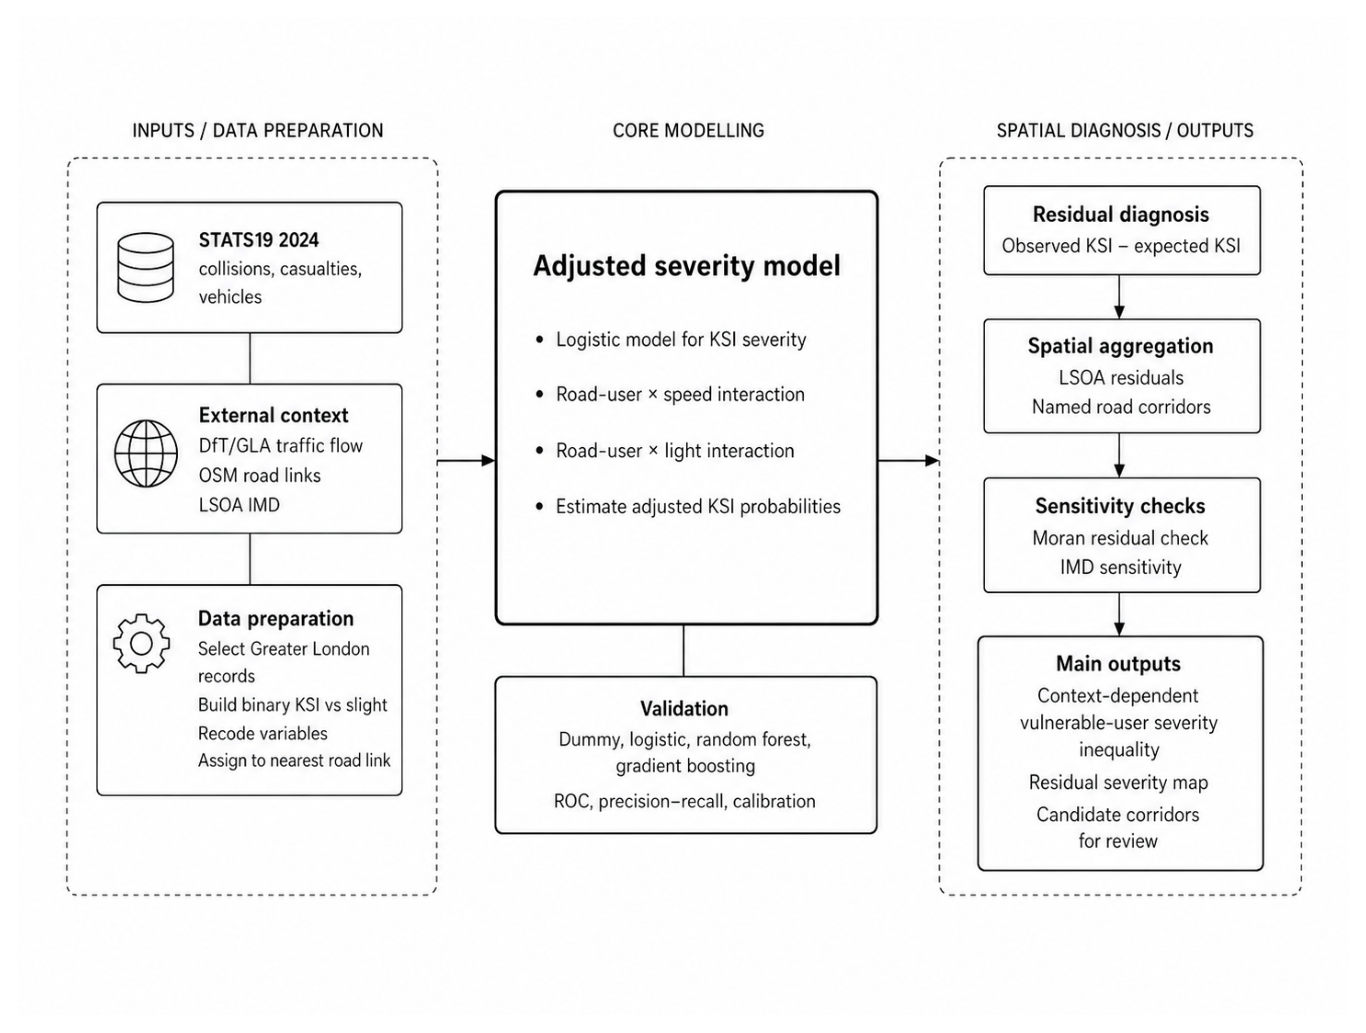

In [5]:
framework_path = ensure_file("framework.png", "framework.png")
framework_img = plt.imread(framework_path)
fig, ax = plt.subplots(figsize=(11.5, 7.2))
ax.imshow(framework_img)
ax.axis("off")
plt.show()


**Methodological framework.** The framework shows how reported STATS19 casualties, external traffic-flow context, OSM road links, and LSOA neighbourhood data are converted into adjusted severity probabilities, validation checks, residual maps, and named corridor review candidates.


## Results and discussion

[[ go back to the top ]](#Table-of-contents)

Results are organised as a chain of evidence rather than as separate model outputs. First, adjusted marginal probabilities test whether vulnerable-road-user severity is a fixed group difference or changes with road context. Second, held-out validation checks whether fitted probabilities are credible enough to serve as an expected-severity baseline. Third, observed-minus-expected residuals are mapped and normalised by assigned road length to identify places that merit review, while deprivation and spatial-neighbour checks prevent the corridor list from being read as a raw-count ranking.


### The vulnerable-user severity gap is context-dependent, not fixed.

Figure 1 shows that pedestrians, cyclists, and motorcyclists remain above car/taxi occupants after standardising the observed casualty mix. The important result is not only the existence of this gap, but its changing size: pedestrian severity rises especially in faster road environments and darkness, while car/taxi severity remains comparatively low. Figure 2 converts the same model output into the inequality scale used by the research question. The positive excess probabilities show that vulnerable-user severity is not a single city-wide difference; it is conditional on the road environment.


In [6]:
model_groups = ["Pedestrian", "Cyclist", "Motorcyclist", "Car/taxi occupant", "Bus/coach occupant", "Goods/van occupant"]
model_df = df[df["road_user_group"].isin(model_groups)].copy()

categorical_features = [
    "road_user_group", "speed_band", "light_group", "user_speed", "user_light",
    "road_type", "junction_detail", "junction_control", "pedestrian_crossing",
    "weather_conditions", "road_surface_conditions", "vehicle_type", "vehicle_manoeuvre",
    "junction_location", "skidding_and_overturning", "vehicle_leaving_carriageway",
    "first_point_of_impact", "sex_of_casualty", "age_band_of_casualty",
    "casualty_imd_decile", "time_period", "month", "traffic_flow_band",
]
numeric_features = ["number_of_vehicles", "car_share_traffic"]

X = model_df[categorical_features + numeric_features].copy()
y = model_df["ksi"].astype(int)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

explain_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2500, C=5.0, solver="liblinear")),
])
explain_model.fit(X, y)


def standardised_probs(model, base, variable, values, group_values=model_groups[:4]):
    rows = []
    base = base.copy()
    for group in group_values:
        for value in values:
            scenario = base.copy()
            scenario["road_user_group"] = group
            scenario[variable] = value
            scenario["user_speed"] = scenario["road_user_group"] + " | " + scenario["speed_band"]
            scenario["user_light"] = scenario["road_user_group"] + " | " + scenario["light_group"]
            rows.append({"road_user_group": group, variable: value, "prob": model.predict_proba(scenario[categorical_features + numeric_features])[:, 1].mean()})
    return pd.DataFrame(rows)


speed_scenarios = [s for s in speed_order if s != "Unknown"]
light_scenarios = ["Daylight", "Darkness-lit", "Darkness-unlit"]
speed_probs = standardised_probs(explain_model, X, "speed_band", speed_scenarios)
light_probs = standardised_probs(explain_model, X, "light_group", light_scenarios)

# Bootstrap uncertainty for the plotted adjusted probabilities.
rng = np.random.default_rng(42)
boot_speed, boot_light = [], []
for b in range(80):
    idx = rng.choice(np.arange(len(model_df)), size=len(model_df), replace=True)
    sample = model_df.iloc[idx]
    sample_X = sample[categorical_features + numeric_features]
    sample_y = sample["ksi"].astype(int)
    try:
        m = Pipeline([
            ("prep", preprocessor),
            ("model", LogisticRegression(max_iter=1800, C=5.0, solver="liblinear")),
        ])
        m.fit(sample_X, sample_y)
        s = standardised_probs(m, X, "speed_band", speed_scenarios)
        l = standardised_probs(m, X, "light_group", light_scenarios)
        s["boot"] = b
        l["boot"] = b
        boot_speed.append(s)
        boot_light.append(l)
    except Exception:
        continue
boot_speed = pd.concat(boot_speed, ignore_index=True)
boot_light = pd.concat(boot_light, ignore_index=True)

def add_ci(point_df, boot_df, variable):
    ci = boot_df.groupby(["road_user_group", variable])["prob"].quantile([0.025, 0.975]).unstack().reset_index()
    ci.columns = ["road_user_group", variable, "low", "high"]
    return point_df.merge(ci, on=["road_user_group", variable], how="left")

speed_probs = add_ci(speed_probs, boot_speed, "speed_band")
light_probs = add_ci(light_probs, boot_light, "light_group")


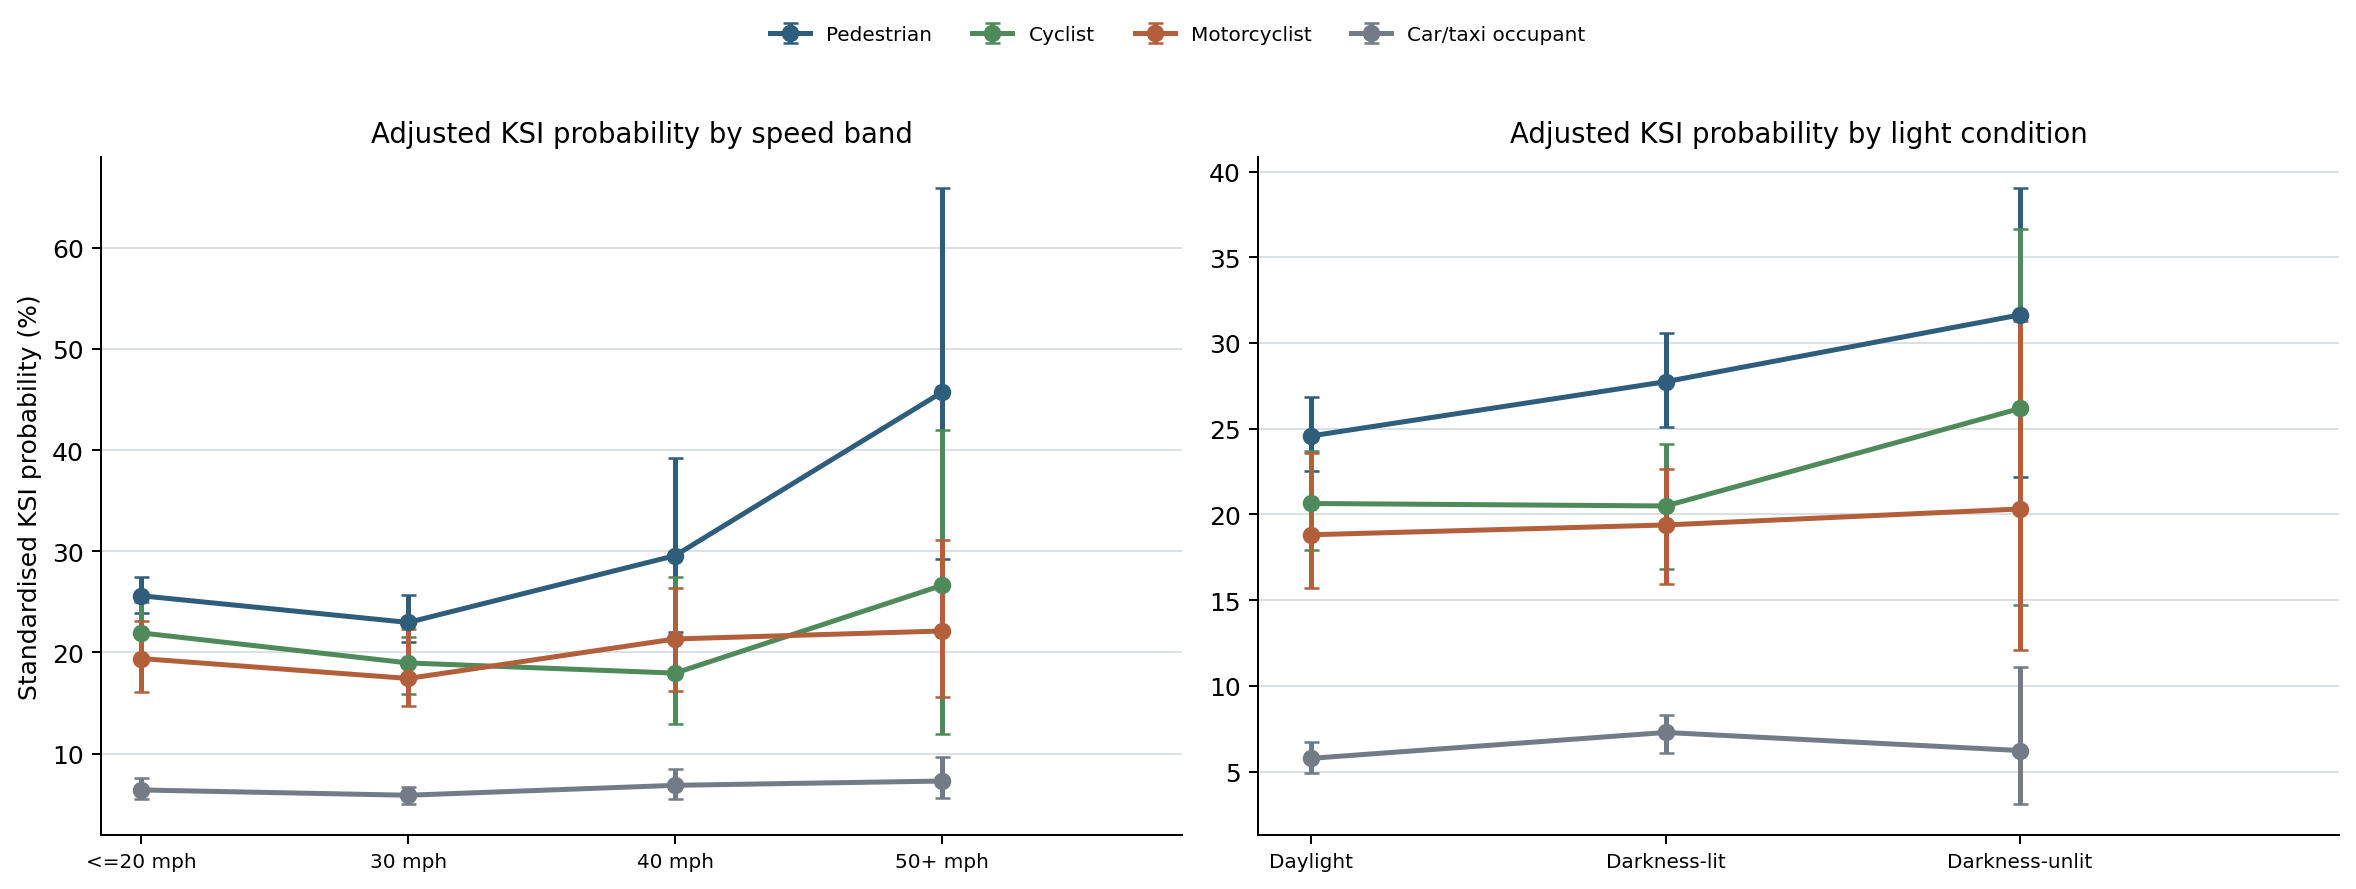

In [7]:
palette = {
    "Pedestrian": "#2F5D7C",
    "Cyclist": "#4F8A5B",
    "Motorcyclist": "#B45F3C",
    "Car/taxi occupant": "#737B86",
}
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
for ax, probs, variable, order, title in [
    (axes[0], speed_probs, "speed_band", speed_scenarios, "Adjusted KSI probability by speed band"),
    (axes[1], light_probs, "light_group", light_scenarios, "Adjusted KSI probability by light condition"),
]:
    for group in model_groups[:4]:
        sub = probs[probs["road_user_group"] == group].set_index(variable).reindex(order).reset_index()
        x = np.arange(len(order))
        yvals = 100 * sub["prob"].to_numpy()
        yerr_low = yvals - 100 * sub["low"].to_numpy()
        yerr_high = 100 * sub["high"].to_numpy() - yvals
        ax.errorbar(x, yvals, yerr=[yerr_low, yerr_high], marker="o", lw=2, capsize=3, label=group, color=palette[group])
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order, fontsize=8)
    ax.set_ylabel("Standardised KSI probability (%)")
    ax.set_title(title, fontsize=11)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#d6dce2", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-0.15, len(order) - 0.10)
axes[1].set_ylabel("")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=4, frameon=False, fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


**Figure 1. Adjusted KSI probability by road-user group, speed, and lighting condition.**

Vulnerable users have higher adjusted KSI probabilities than car/taxi occupants across comparable settings, but the gap widens in faster and darker road environments. Wider intervals in rare categories should be read as uncertainty rather than precise point estimates.


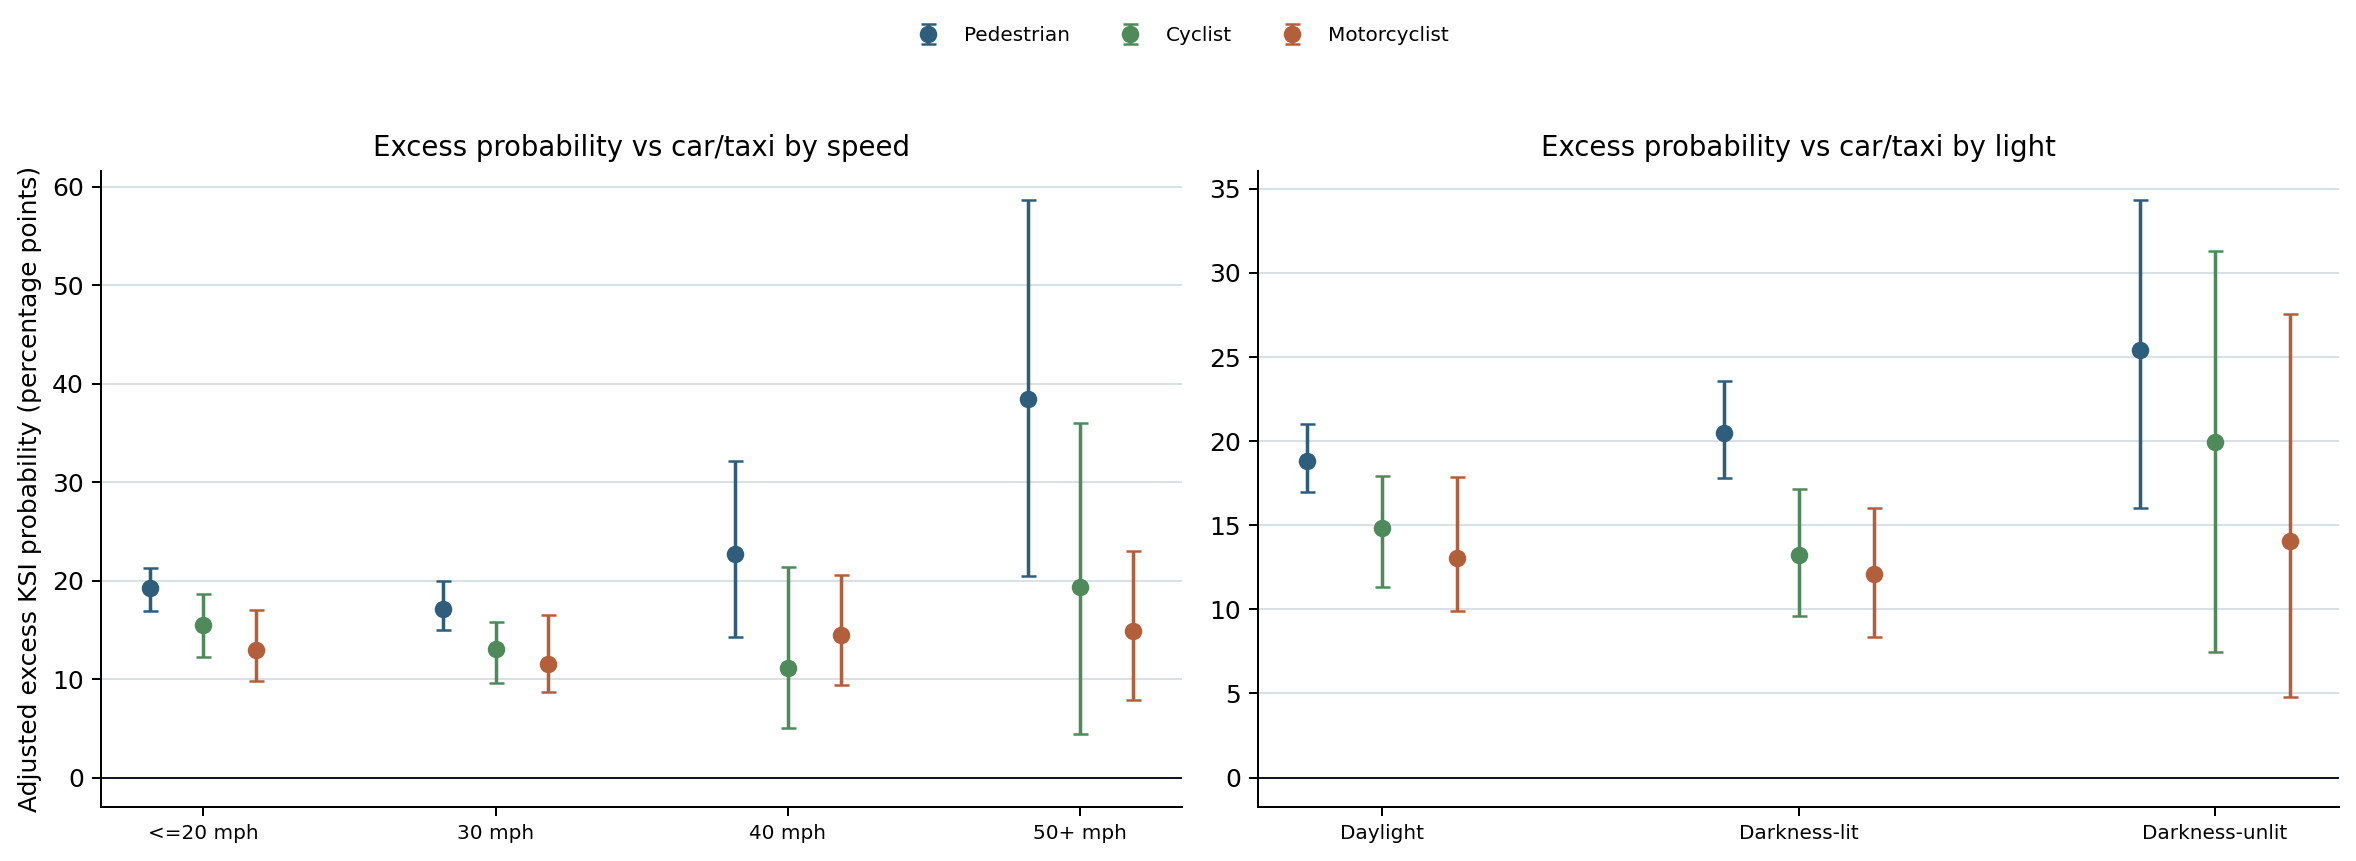

In [8]:
def adjusted_gap(point_df, boot_df, variable, order):
    baseline = point_df[point_df["road_user_group"] == "Car/taxi occupant"].set_index(variable)["prob"]
    rows = []
    for group in ["Pedestrian", "Cyclist", "Motorcyclist"]:
        sub = point_df[point_df["road_user_group"] == group].set_index(variable)
        boot_gaps = []
        for _, boot_sub in boot_df.groupby("boot"):
            pivot = boot_sub.pivot(index=variable, columns="road_user_group", values="prob")
            if group in pivot and "Car/taxi occupant" in pivot:
                boot_gaps.append((pivot[group] - pivot["Car/taxi occupant"]).reindex(order))
        boot_gaps = pd.concat(boot_gaps, axis=1).T if boot_gaps else pd.DataFrame(columns=order)
        for value in order:
            gap = 100 * (sub.loc[value, "prob"] - baseline.loc[value])
            rows.append({
                "road_user_group": group,
                variable: value,
                "gap_pct": gap,
                "low": 100 * boot_gaps[value].quantile(0.025) if value in boot_gaps else np.nan,
                "high": 100 * boot_gaps[value].quantile(0.975) if value in boot_gaps else np.nan,
            })
    return pd.DataFrame(rows)

speed_gap = adjusted_gap(speed_probs, boot_speed, "speed_band", speed_scenarios)
light_gap = adjusted_gap(light_probs, boot_light, "light_group", light_scenarios)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))
for ax, gaps, variable, order, title in [
    (axes[0], speed_gap, "speed_band", speed_scenarios, "Excess probability vs car/taxi by speed"),
    (axes[1], light_gap, "light_group", light_scenarios, "Excess probability vs car/taxi by light"),
]:
    offsets = {"Pedestrian": -0.18, "Cyclist": 0.0, "Motorcyclist": 0.18}
    for group in ["Pedestrian", "Cyclist", "Motorcyclist"]:
        sub = gaps[gaps["road_user_group"] == group].set_index(variable).reindex(order).reset_index()
        x = np.arange(len(order)) + offsets[group]
        yvals = sub["gap_pct"].to_numpy()
        yerr = np.vstack([
            np.maximum(yvals - sub["low"].to_numpy(), 0),
            np.maximum(sub["high"].to_numpy() - yvals, 0),
        ])
        ax.errorbar(x, yvals, yerr=yerr, marker="o", lw=0, elinewidth=1.4, capsize=3, label=group, color=palette[group])
    ax.axhline(0, color="#111827", linewidth=0.8)
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order, fontsize=8)
    ax.set_ylabel("Adjusted excess KSI probability (percentage points)")
    ax.set_title(title, fontsize=11)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#d6dce2", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].set_ylabel("")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=False, fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


**Figure 2. Excess KSI probability relative to car/taxi occupants.**

By subtracting the car/taxi baseline under the same standardised casualty mix, the figure shows that vulnerable-user severity inequality is positive in most contexts but not constant across road environments.


### The model supports residual diagnosis, but not strong individual prediction.

Validation is used here to bound the interpretation of the spatial results. Figure 3 shows that the supervised models outperform a dummy baseline, yet precision-recall performance remains modest because KSI is a minority outcome and many severe outcomes are not fully captured by recorded STATS19 variables. Figure 4 shows that predicted deciles are ordered, but absolute probabilities are imperfectly calibrated under class weighting. The residual maps should therefore be interpreted as comparative diagnostics of higher-than-expected severity, not as exact predictions of individual casualty outcomes.


In [9]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
models = {
    "Dummy baseline": Pipeline([("prep", preprocessor), ("model", DummyClassifier(strategy="prior"))]),
    "Class-weighted logistic": Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1800, class_weight="balanced", solver="liblinear"))]),
    "Random forest": Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(n_estimators=220, min_samples_leaf=8, class_weight="balanced_subsample", random_state=42, n_jobs=1))]),
    "Gradient boosting": Pipeline([("prep", preprocessor), ("model", GradientBoostingClassifier(random_state=42, n_estimators=120, learning_rate=0.05, max_depth=3))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name, pipe in models.items():
    cv_prob = cross_val_predict(pipe, train_X, train_y, cv=cv, method="predict_proba", n_jobs=None)[:, 1]
    precision, recall, thresholds = precision_recall_curve(train_y, cv_prob)
    f1_scores = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-9)
    threshold = thresholds[np.argmax(f1_scores)] if len(thresholds) else 0.5
    pipe.fit(train_X, train_y)
    test_prob = pipe.predict_proba(test_X)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)
    cv_rows.append({
        "model": name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(test_y, test_prob),
        "average_precision": average_precision_score(test_y, test_prob),
        "f1": f1_score(test_y, test_pred),
        "cm": confusion_matrix(test_y, test_pred),
        "pipe": pipe,
        "test_prob": test_prob,
        "test_pred": test_pred,
    })
model_results = pd.DataFrame(cv_rows).sort_values(["average_precision", "roc_auc"], ascending=False)
best = model_results.iloc[0]
best_model_name = best["model"]
best_pipe = best["pipe"]
print(model_results[["model", "roc_auc", "average_precision", "f1", "threshold"]].to_string(index=False))


                  model  roc_auc  average_precision       f1  threshold
Class-weighted logistic 0.776536           0.395994 0.423956   0.595596
      Gradient boosting 0.778063           0.388898 0.420875   0.186635
          Random forest 0.774547           0.376665 0.428469   0.503666
         Dummy baseline 0.500000           0.153366 0.265945   0.153322


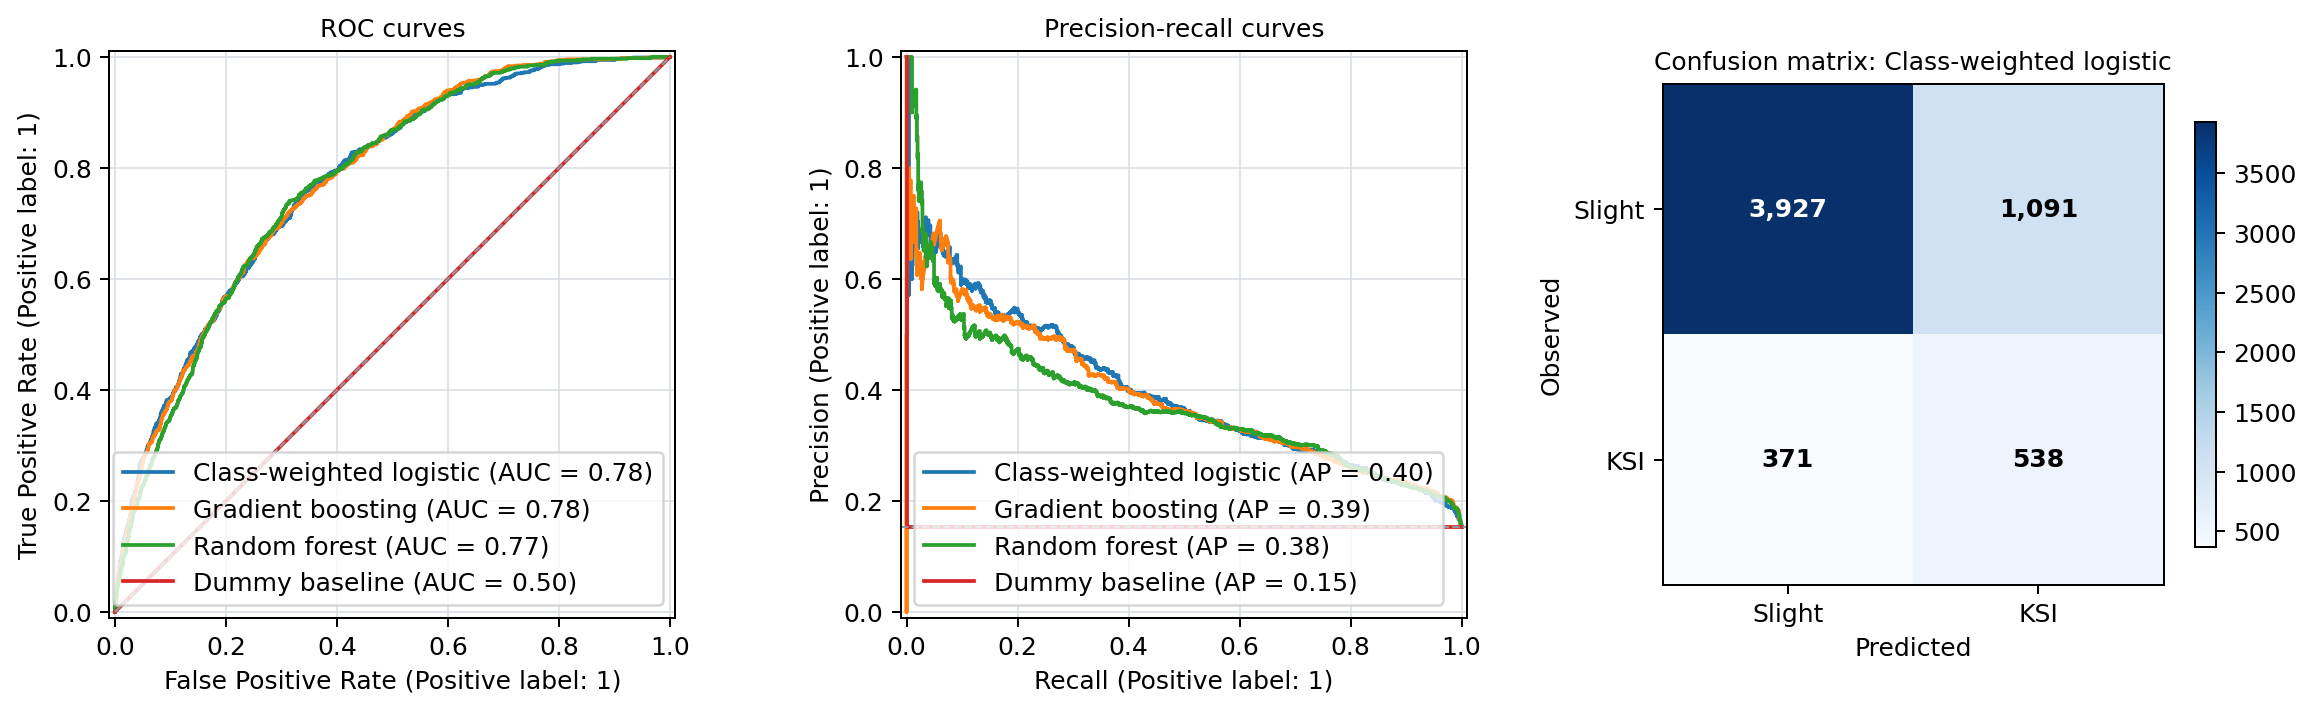

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0))
for _, row in model_results.iterrows():
    RocCurveDisplay.from_predictions(test_y, row["test_prob"], ax=axes[0], name=row["model"])
axes[0].plot([0, 1], [0, 1], color="#9099a5", linestyle="--", lw=0.8)
axes[0].set_title("ROC curves", fontsize=10)
axes[0].grid(color="#d6dce2", linewidth=0.6)

for _, row in model_results.iterrows():
    PrecisionRecallDisplay.from_predictions(test_y, row["test_prob"], ax=axes[1], name=row["model"])
axes[1].axhline(test_y.mean(), color="#9099a5", linestyle="--", lw=0.8)
axes[1].set_title("Precision-recall curves", fontsize=10)
axes[1].grid(color="#d6dce2", linewidth=0.6)

cm = best["cm"]
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Slight", "KSI"])
axes[2].set_yticklabels(["Slight", "KSI"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Observed")
axes[2].set_title(f"Confusion matrix: {best_model_name}", fontsize=10)
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontweight="bold")
plt.colorbar(im, ax=axes[2], shrink=0.75)
plt.tight_layout()
plt.show()


**Figure 3. Held-out model validation.**

The supervised models improve on the dummy baseline, but modest precision-recall performance shows that the model should not be interpreted as a strong individual-level prediction tool.


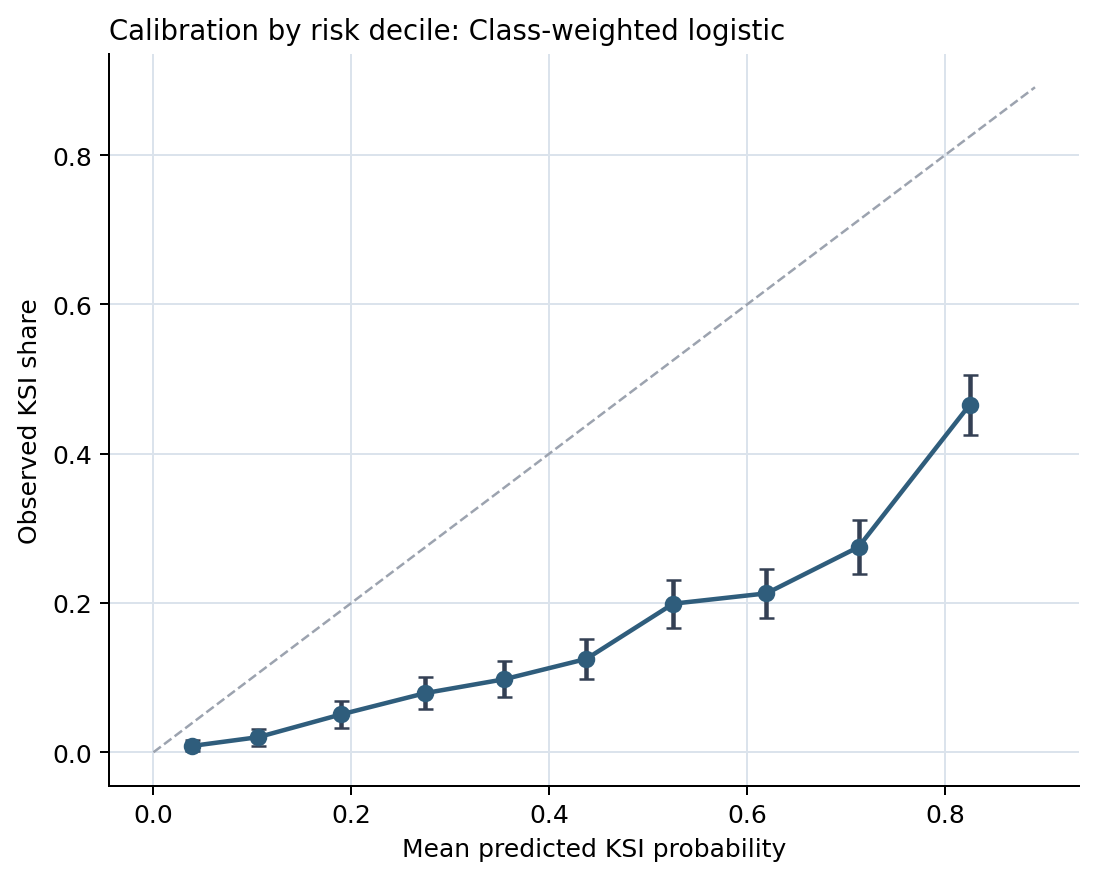

In [11]:
calibration = pd.DataFrame({"observed": test_y.to_numpy(), "predicted": best["test_prob"]})
calibration["risk_decile"] = pd.qcut(calibration["predicted"].rank(method="first"), 10, labels=False) + 1
cal_summary = (
    calibration.groupby("risk_decile")
    .agg(
        mean_predicted=("predicted", "mean"),
        observed_rate=("observed", "mean"),
        n=("observed", "size"),
    )
    .reset_index()
)
cal_summary["se"] = np.sqrt(cal_summary["observed_rate"] * (1 - cal_summary["observed_rate"]) / cal_summary["n"])

fig, ax = plt.subplots(figsize=(6.2, 5.0))
ax.plot([0, cal_summary["mean_predicted"].max() * 1.08], [0, cal_summary["mean_predicted"].max() * 1.08], color="#9ca3af", linestyle="--", lw=1)
ax.errorbar(
    cal_summary["mean_predicted"],
    cal_summary["observed_rate"],
    yerr=1.96 * cal_summary["se"],
    marker="o",
    lw=1.8,
    color="#2f5d7c",
    ecolor="#344054",
    capsize=3,
)
ax.set_xlabel("Mean predicted KSI probability")
ax.set_ylabel("Observed KSI share")
ax.set_title(f"Calibration by risk decile: {best_model_name}", fontsize=11, loc="left")
ax.set_axisbelow(True)
ax.grid(color="#dbe3ec", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Figure 4. Risk-ranking and calibration check for the residual baseline.**

Predicted-risk deciles are ordered, which supports relative residual diagnosis, but the class-weighted model over-predicts absolute KSI probability. Residuals are therefore interpreted as comparative diagnostics rather than exact expected casualty counts.


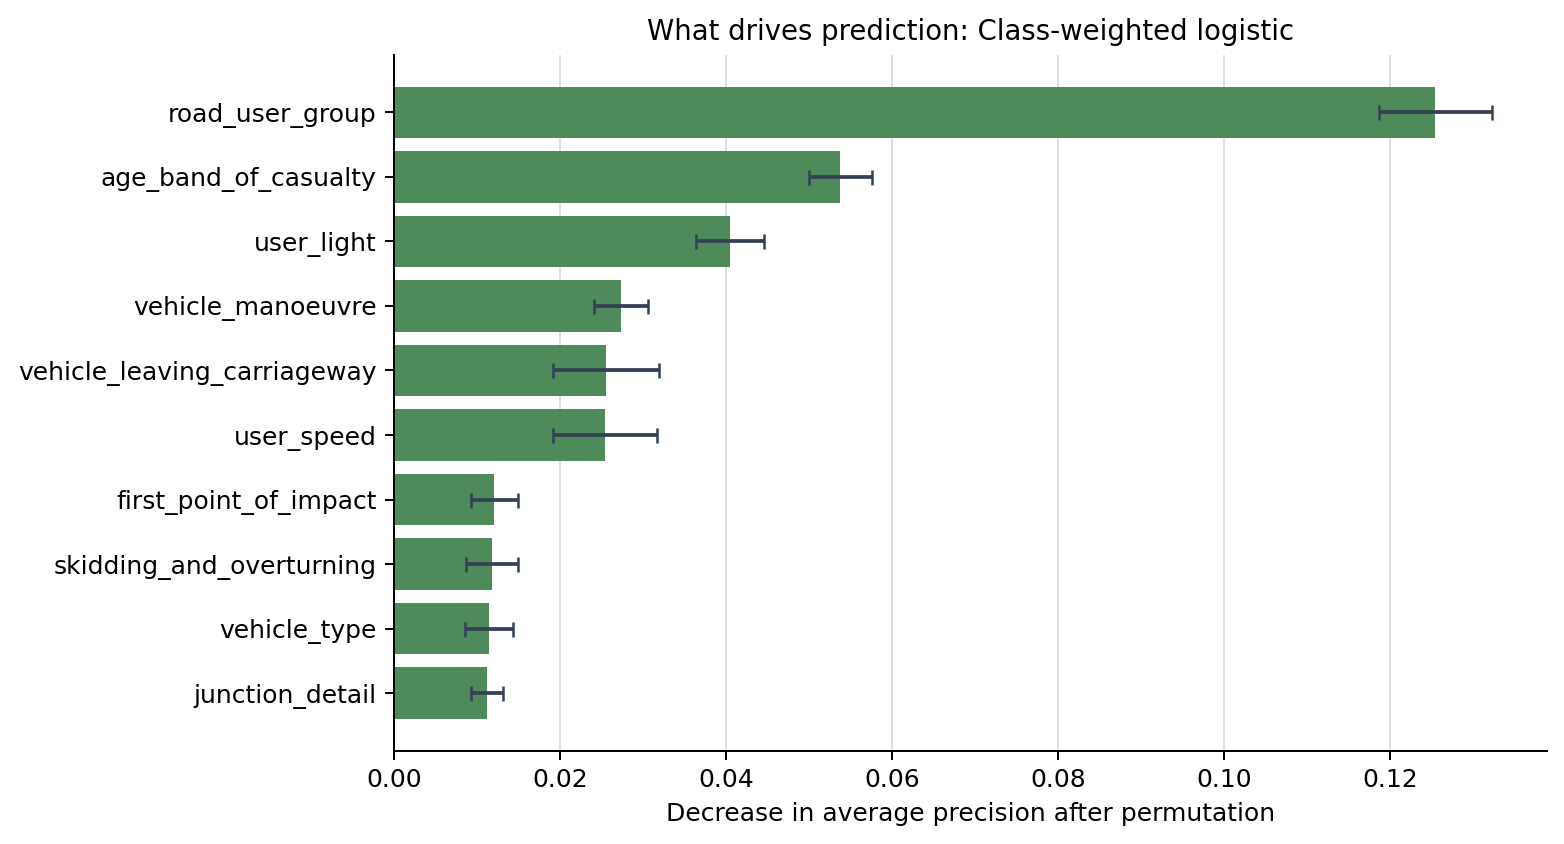

In [12]:
perm = permutation_importance(best_pipe, test_X, test_y, n_repeats=10, random_state=42, scoring="average_precision", n_jobs=1)
perm_df = pd.DataFrame({
    "feature": categorical_features + numeric_features,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
plot_df = perm_df.sort_values("importance", ascending=True)
ax.barh(plot_df["feature"], plot_df["importance"], xerr=plot_df["std"], color="#4F8A5B", ecolor="#344054", capsize=3)
ax.set_xlabel("Decrease in average precision after permutation")
ax.set_title(f"What drives prediction: {best_model_name}", fontsize=11)
ax.set_axisbelow(True)
ax.grid(axis="x", color="#d6dce2", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Figure 5. Feature signal in the validated model.**

Permutation importance shows that road-user group and context-related variables carry the main signal, which is consistent with the corridor residual interpretation while avoiding a claim of individual-level prediction.
Together, Figures 3-5 justify the residual maps as a diagnostic baseline while keeping the claim appropriately limited: the model can rank expected severity better than a dummy baseline, but it cannot explain every severe outcome recorded in STATS19.


### Residuals translate the model into spatial review priorities.

Figure 6 maps where observed KSI exceeds model expectation after adjustment, while the Moran diagnostic tests whether neighbouring LSOAs share similar residuals. The weak global pattern means that the map is better read as a local diagnostic surface than as evidence of one strong London-wide cluster. Figure 7 adds a deprivation sensitivity check: residual severity does not increase monotonically with IMD decile, so the spatial pattern is not simply a deprivation map. Figure 8 then separates spatially reinforced excess from isolated local residuals, providing a clearer basis for prioritising places for review.


In [13]:
explain_model.fit(X, y)
model_df["predicted_ksi"] = explain_model.predict_proba(X)[:, 1]
model_df["residual_ksi"] = model_df["ksi"] - model_df["predicted_ksi"]
model_df["residual_var"] = model_df["predicted_ksi"] * (1 - model_df["predicted_ksi"])

point_cols = ["collision_index", "location_easting_osgr", "location_northing_osgr", "local_authority_ons_district"]
collision_points = london_collisions[point_cols].dropna(subset=["location_easting_osgr", "location_northing_osgr"]).copy()
collision_points = gpd.GeoDataFrame(
    collision_points,
    geometry=gpd.points_from_xy(collision_points["location_easting_osgr"], collision_points["location_northing_osgr"]),
    crs="EPSG:27700",
)
edge_cols = ["edge_uid", "name", "highway", "length", "geometry"]
edge_lookup = edges[edge_cols].copy()
assigned = gpd.sjoin_nearest(
    collision_points[["collision_index", "geometry"]],
    edge_lookup,
    how="left",
    max_distance=35,
    distance_col="snap_m",
).drop_duplicates("collision_index")

model_df = model_df.merge(assigned.drop(columns="geometry"), on="collision_index", how="left")
matched_rate = model_df["edge_uid"].notna().mean()
print(f"Casualty records matched to OSM road links within 35m: {matched_rate:.1%}")

seg = model_df.dropna(subset=["edge_uid"]).groupby("edge_uid").agg(
    casualties=("ksi", "size"),
    ksi=("ksi", "sum"),
    vulnerable_ksi=("vulnerable_user", lambda s: int(((s == 1) & (model_df.loc[s.index, "ksi"] == 1)).sum())),
    expected_ksi=("predicted_ksi", "sum"),
    residual_ksi=("residual_ksi", "sum"),
    residual_var=("residual_var", "sum"),
    mean_snap_m=("snap_m", "mean"),
).reset_index()
seg["ksi_rate_pct"] = 100 * seg["ksi"] / seg["casualties"]
seg["residual_per_100_casualties"] = 100 * seg["residual_ksi"] / seg["casualties"]
seg_gdf = edge_lookup.merge(seg, on="edge_uid", how="inner")

def normalise_label(value):
    if isinstance(value, list):
        return ", ".join(map(str, value[:2]))
    if pd.isna(value):
        return "Unnamed road"
    return str(value)

seg_gdf["road_label"] = seg_gdf["name"].map(normalise_label)
seg_gdf["highway_label"] = seg_gdf["highway"].map(normalise_label)

edge_midpoints = seg_gdf[["edge_uid", "geometry"]].copy()
edge_midpoints["geometry"] = edge_midpoints.geometry.interpolate(0.5, normalized=True)
edge_boroughs = gpd.sjoin(
    gpd.GeoDataFrame(edge_midpoints, geometry="geometry", crs=seg_gdf.crs),
    boroughs[["name", "geometry"]].rename(columns={"name": "borough_name"}),
    how="left",
    predicate="within",
)[["edge_uid", "borough_name"]].drop_duplicates("edge_uid")
seg_gdf = seg_gdf.merge(edge_boroughs, on="edge_uid", how="left")
seg_gdf["borough_name"] = seg_gdf["borough_name"].fillna("Greater London")
seg_gdf["corridor_label"] = np.where(
    seg_gdf["road_label"].eq("Unnamed road"),
    "Unnamed road",
    seg_gdf["road_label"] + " (" + seg_gdf["borough_name"] + ")",
)

lsoa_lookup = pd.read_excel(
    local_or_url("london_lsoa_imd2019.xlsx"),
    sheet_name="IMD 2019",
    usecols=[
        "LSOA code (2011)",
        "LSOA name (2011)",
        "Index of Multiple Deprivation (IMD) Score",
        "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",
    ],
).rename(columns={
    "LSOA code (2011)": "lsoa_of_accident_location",
    "LSOA name (2011)": "lsoa_name",
    "Index of Multiple Deprivation (IMD) Score": "imd_score",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile",
})
lsoa_boundaries = gpd.read_file(ensure_lsoa_boundaries(lsoa_lookup["lsoa_of_accident_location"]))
if lsoa_boundaries.crs is None:
    lsoa_boundaries = lsoa_boundaries.set_crs("EPSG:4326")
lsoa_boundaries = lsoa_boundaries.to_crs("EPSG:27700")
lsoa_summary = (
    model_df.dropna(subset=["lsoa_of_accident_location", "location_easting_osgr", "location_northing_osgr"])
    .groupby("lsoa_of_accident_location")
    .agg(
        casualties=("ksi", "size"),
        ksi=("ksi", "sum"),
        expected_ksi=("predicted_ksi", "sum"),
        residual_ksi=("residual_ksi", "sum"),
    )
    .reset_index()
)
lsoa_summary["residual_per_100_casualties"] = 100 * lsoa_summary["residual_ksi"] / lsoa_summary["casualties"]
lsoa_summary = lsoa_summary.merge(lsoa_lookup, on="lsoa_of_accident_location", how="left")

road_rank = (
    seg_gdf
    .groupby(["corridor_label", "road_label", "borough_name"])
    .agg(
        casualties=("casualties", "sum"),
        ksi=("ksi", "sum"),
        expected_ksi=("expected_ksi", "sum"),
        residual_ksi=("residual_ksi", "sum"),
        residual_var=("residual_var", "sum"),
        corridor_length_m=("length", "sum"),
    )
    .reset_index()
)
road_rank["corridor_length_km"] = road_rank["corridor_length_m"] / 1000
road_rank = road_rank[
    (road_rank["road_label"] != "Unnamed road")
    & (road_rank["casualties"] >= 6)
    & (road_rank["corridor_length_km"] >= 0.25)
    & (road_rank["residual_ksi"] > 0)
].copy()
road_rank["residual_per_100_casualties"] = 100 * road_rank["residual_ksi"] / road_rank["casualties"]
road_rank["residual_per_km"] = road_rank["residual_ksi"] / road_rank["corridor_length_km"]
road_rank["residual_se"] = np.sqrt(road_rank["residual_var"])
road_rank["residual_per_km_low"] = (road_rank["residual_ksi"] - 1.96 * road_rank["residual_se"]) / road_rank["corridor_length_km"]
road_rank["residual_per_km_high"] = (road_rank["residual_ksi"] + 1.96 * road_rank["residual_se"]) / road_rank["corridor_length_km"]
road_rank = road_rank.sort_values("residual_per_km", ascending=False).head(8)


Casualty records matched to OSM road links within 35m: 99.4%


Global Moran's I for LSOA residuals: 0.010; permutation p=0.788; LSOAs with n>=8: 896


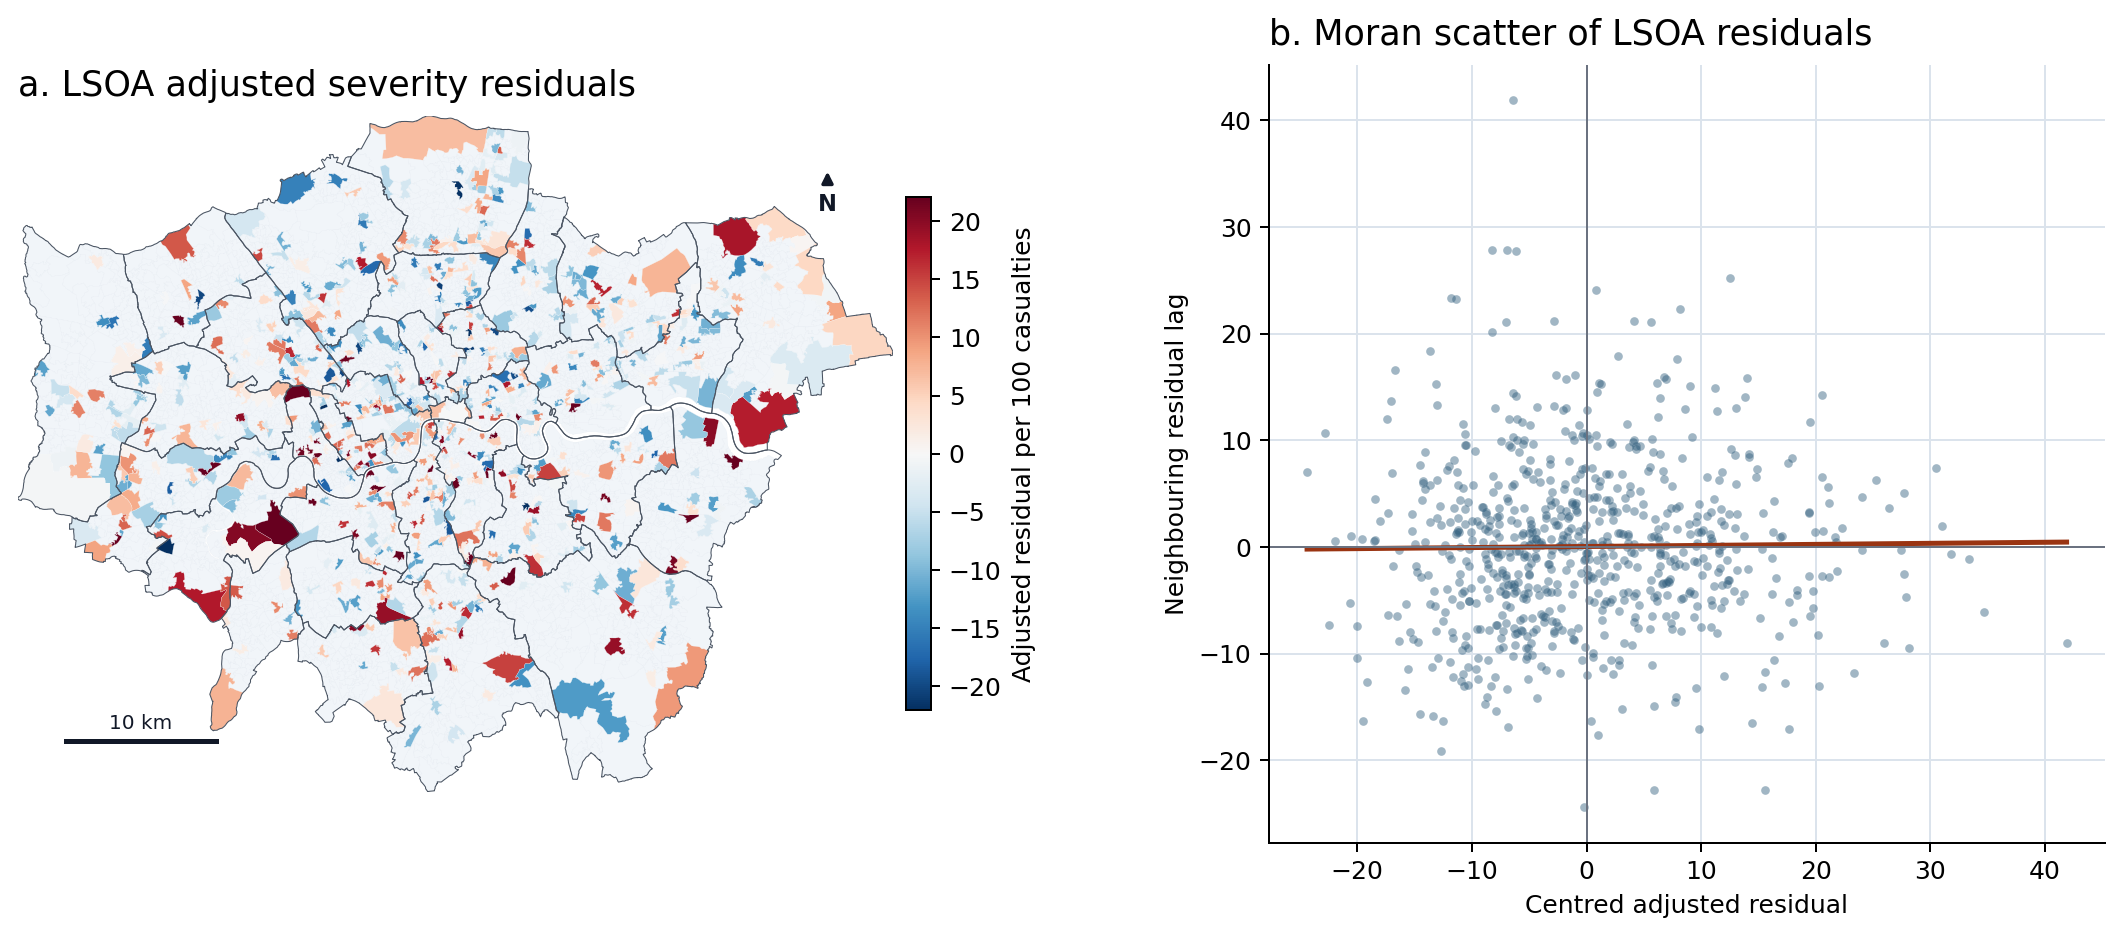

In [14]:
def lines_to_collection(gdf):
    return []

code_col = "LSOA11CD" if "LSOA11CD" in lsoa_boundaries.columns else "lsoa_of_accident_location"
lsoa_map = lsoa_boundaries.merge(
    lsoa_summary,
    left_on=code_col,
    right_on="lsoa_of_accident_location",
    how="left",
)
lsoa_diag = lsoa_map[(lsoa_map["casualties"] >= 8) & lsoa_map["residual_per_100_casualties"].notna()].copy().reset_index(drop=True)
resid_values = lsoa_diag["residual_per_100_casualties"].to_numpy()
resid_limit = max(np.nanpercentile(np.abs(resid_values), 97), 1)

def queen_neighbours(gdf):
    sindex = gdf.sindex
    neighbours = []
    for idx, geom in enumerate(gdf.geometry):
        candidates = [int(j) for j in sindex.query(geom, predicate="touches") if int(j) != idx]
        neighbours.append(np.array(candidates, dtype=int))
    return neighbours

def moran_i(values, neighbours, permutations=499, seed=42):
    x = np.asarray(values, dtype=float)
    z = x - np.nanmean(x)
    valid = np.array([len(n) > 0 for n in neighbours])
    lag = np.full(len(z), np.nan)
    for i, n in enumerate(neighbours):
        if len(n):
            lag[i] = z[n].mean()
    numerator = np.nansum(z[valid] * lag[valid])
    denominator = np.nansum(z[valid] ** 2)
    observed = numerator / denominator if denominator else np.nan
    rng = np.random.default_rng(seed)
    sims = []
    for _ in range(permutations):
        zp = rng.permutation(z)
        lagp = np.full(len(zp), np.nan)
        for i, n in enumerate(neighbours):
            if len(n):
                lagp[i] = zp[n].mean()
        sims.append(np.nansum(zp[valid] * lagp[valid]) / denominator if denominator else np.nan)
    sims = np.asarray(sims)
    p_value = (np.sum(np.abs(sims) >= abs(observed)) + 1) / (len(sims) + 1)
    return observed, p_value, z, lag

neighbours = queen_neighbours(lsoa_diag)
moran_observed, moran_p, moran_x, moran_lag = moran_i(resid_values, neighbours)
print(f"Global Moran's I for LSOA residuals: {moran_observed:.3f}; permutation p={moran_p:.3f}; LSOAs with n>=8: {len(lsoa_diag):,}")

fig = plt.figure(figsize=(12.6, 5.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1.0], wspace=0.22)
minx, miny, maxx, maxy = boroughs.total_bounds
width, height = maxx - minx, maxy - miny

def finish_map(ax, title):
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, loc="left", pad=8)
    sx, sy = minx + 0.055 * width, miny + 0.075 * height
    ax.plot([sx, sx + 10000], [sy, sy], color="#111827", lw=2.0, zorder=6)
    ax.text(sx + 5000, sy + 0.018 * height, "10 km", ha="center", fontsize=8, color="#111827")
    nx, ny = maxx - 0.075 * width, maxy - 0.14 * height
    ax.annotate("N", xy=(nx, ny + 0.065 * height), xytext=(nx, ny), arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#111827"), ha="center", fontsize=9, fontweight="bold", color="#111827")

def corridor_axis_label(row):
    return f"{row['road_label']}\n{row['borough_name']}"

ax = fig.add_subplot(gs[0])
ax.set_facecolor("#f8fafc")
lsoa_map.plot(ax=ax, color="#f1f5f9", edgecolor="#dbe3ec", linewidth=0.05, zorder=1)
if len(lsoa_diag):
    lsoa_diag.plot(
        column="residual_per_100_casualties",
        ax=ax,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vcenter=0, vmin=-resid_limit, vmax=resid_limit),
        edgecolor="#ffffff",
        linewidth=0.08,
        legend=True,
        legend_kwds={"label": "Adjusted residual per 100 casualties", "shrink": 0.66, "pad": 0.012},
        zorder=2,
    )
boroughs.boundary.plot(ax=ax, color="#4b5563", linewidth=0.42, zorder=3)
finish_map(ax, "a. LSOA adjusted severity residuals")

ax = fig.add_subplot(gs[1])
valid = np.isfinite(moran_x) & np.isfinite(moran_lag)
ax.scatter(moran_x[valid], moran_lag[valid], s=12, color="#2f5d7c", alpha=0.45, linewidth=0)
if valid.sum() > 2:
    slope, intercept = np.polyfit(moran_x[valid], moran_lag[valid], 1)
    xs = np.linspace(np.nanmin(moran_x[valid]), np.nanmax(moran_x[valid]), 100)
    ax.plot(xs, intercept + slope * xs, color="#9a3412", lw=2)
ax.axhline(0, color="#6b7280", lw=0.8)
ax.axvline(0, color="#6b7280", lw=0.8)
ax.set_title("b. Moran scatter of LSOA residuals", fontsize=14, loc="left", pad=8)
ax.set_xlabel("Centred adjusted residual")
ax.set_ylabel("Neighbouring residual lag")
ax.set_axisbelow(True)
ax.grid(color="#dbe3ec", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
fig.subplots_adjust(left=0.04, right=0.96, top=0.92, bottom=0.12)
plt.show()


**Figure 6. Spatial residual diagnostics.**

Panel a maps where observed KSI exceeds model expectation after adjustment, while panel b tests whether neighbouring LSOAs share similar residuals. The weak global pattern means that the map is better read as a local diagnostic surface than as evidence of one strong London-wide cluster.


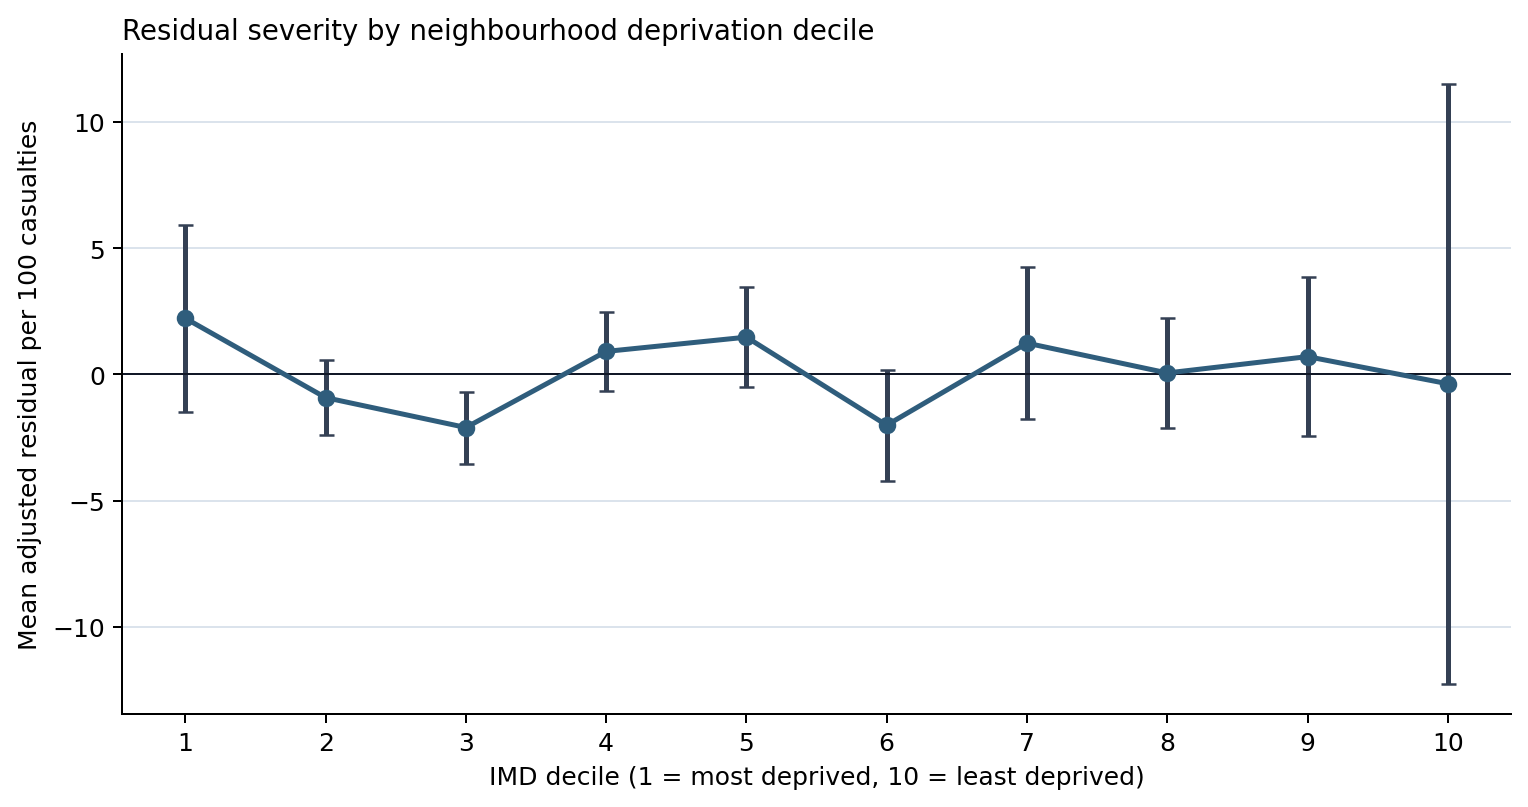

In [15]:
imd_diag = lsoa_diag.dropna(subset=["imd_decile", "residual_per_100_casualties"]).copy()
imd_diag["imd_decile"] = imd_diag["imd_decile"].astype(int)
imd_summary = (
    imd_diag.groupby("imd_decile")
    .agg(
        mean_residual=("residual_per_100_casualties", "mean"),
        se_residual=("residual_per_100_casualties", lambda s: s.std(ddof=1) / np.sqrt(len(s))),
        n=("residual_per_100_casualties", "size"),
    )
    .reset_index()
    .sort_values("imd_decile")
)

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = imd_summary["imd_decile"].to_numpy()
y = imd_summary["mean_residual"].to_numpy()
yerr = 1.96 * imd_summary["se_residual"].fillna(0).to_numpy()
ax.errorbar(x, y, yerr=yerr, marker="o", color="#2f5d7c", ecolor="#344054", capsize=3, lw=2)
ax.axhline(0, color="#111827", linewidth=0.8)
ax.set_xticks(range(1, 11))
ax.set_xlabel("IMD decile (1 = most deprived, 10 = least deprived)")
ax.set_ylabel("Mean adjusted residual per 100 casualties")
ax.set_title("Residual severity by neighbourhood deprivation decile", fontsize=11, loc="left")
ax.set_axisbelow(True)
ax.grid(axis="y", color="#dbe3ec", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Figure 7. Deprivation sensitivity of residual severity.**

Residual KSI does not follow a clear monotonic deprivation gradient, suggesting that the corridor diagnosis is not simply reproducing IMD. The wide interval in the least deprived decile warns against over-interpreting sparse categories.


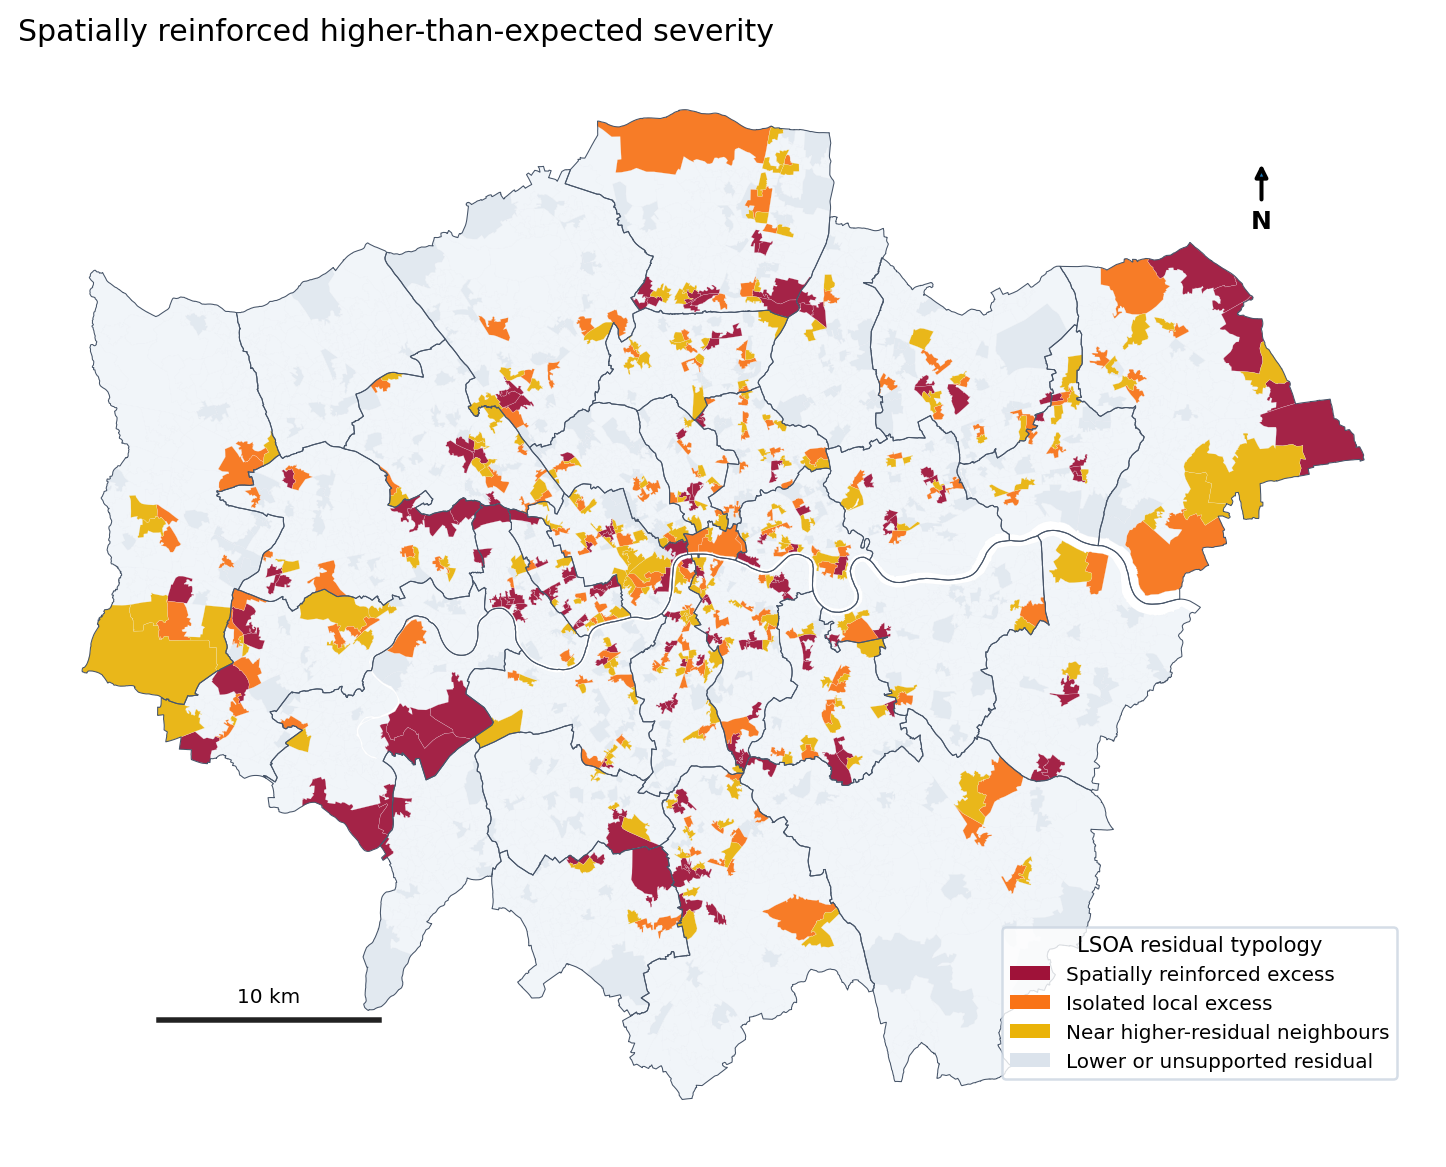

In [16]:
priority_map = lsoa_diag.copy()
priority_map["centred_residual"] = moran_x
priority_map["neighbour_residual_lag"] = moran_lag
priority_map["priority_class"] = "Lower or unsupported residual"
valid_priority = priority_map["centred_residual"].notna() & priority_map["neighbour_residual_lag"].notna()
priority_map.loc[
    valid_priority & (priority_map["centred_residual"] > 0) & (priority_map["neighbour_residual_lag"] > 0),
    "priority_class",
] = "Spatially reinforced excess"
priority_map.loc[
    valid_priority & (priority_map["centred_residual"] > 0) & (priority_map["neighbour_residual_lag"] <= 0),
    "priority_class",
] = "Isolated local excess"
priority_map.loc[
    valid_priority & (priority_map["centred_residual"] <= 0) & (priority_map["neighbour_residual_lag"] > 0),
    "priority_class",
] = "Near higher-residual neighbours"

class_order = [
    "Spatially reinforced excess",
    "Isolated local excess",
    "Near higher-residual neighbours",
]
class_colours = {
    "Spatially reinforced excess": "#9f1239",
    "Isolated local excess": "#f97316",
    "Near higher-residual neighbours": "#eab308",
}

fig, ax = plt.subplots(figsize=(9.8, 6.6))
ax.set_facecolor("#f8fafc")
lsoa_map.plot(ax=ax, color="#f1f5f9", edgecolor="#e2e8f0", linewidth=0.04, zorder=1)
priority_map.plot(ax=ax, color="#dbe3ec", edgecolor="#ffffff", linewidth=0.05, alpha=0.65, zorder=2)
for cls in class_order:
    subset = priority_map[priority_map["priority_class"] == cls]
    if len(subset):
        subset.plot(ax=ax, color=class_colours[cls], edgecolor="#ffffff", linewidth=0.08, alpha=0.92, zorder=3)
boroughs.boundary.plot(ax=ax, color="#475569", linewidth=0.42, zorder=4)
ax.set_title("Spatially reinforced higher-than-expected severity", fontsize=12, loc="left", pad=8)
ax.set_axis_off()
add_map_elements(ax, boroughs.total_bounds, scale_length=10000)
handles = [Patch(facecolor=class_colours[cls], edgecolor="none", label=cls) for cls in class_order]
handles.append(Patch(facecolor="#dbe3ec", edgecolor="none", label="Lower or unsupported residual"))
ax.legend(
    handles=handles,
    title="LSOA residual typology",
    loc="lower right",
    bbox_to_anchor=(0.985, 0.055),
    frameon=True,
    facecolor="white",
    edgecolor="#cbd5e1",
    fontsize=8,
    title_fontsize=8.5,
)
plt.tight_layout()
plt.show()


**Figure 8. Spatially reinforced residual typology.**

The Moran residual typology shows where higher-than-expected severity is reinforced by neighbouring LSOAs. Dark red areas combine positive local residuals with positive neighbouring residual lags; orange areas are more isolated local excesses; yellow areas sit next to higher-residual neighbours and indicate possible spatial spillovers around the diagnostic surface.


Road,Borough,Casualties,Observed KSI,Expected KSI,Excess KSI,Assigned km,Excess KSI/km
Clapham Common South Side,Lambeth,8,6,2.4,3.6,0.28,12.91
Aldwych,Westminster,9,5,1.9,3.1,0.36,8.63
Streatham Hill,Lambeth,7,6,2.0,4.0,0.51,7.75
Mare Street,Hackney,13,5,2.3,2.7,0.37,7.21
Turnpike Lane,Haringey,17,6,2.4,3.6,0.57,6.33
Pentonville Road,Islington,17,8,2.5,5.5,0.96,5.70
Clapham Common North Side,Wandsworth,7,3,0.9,2.1,0.39,5.37
Harlington Road West,Hounslow,8,4,1.5,2.5,0.49,5.11


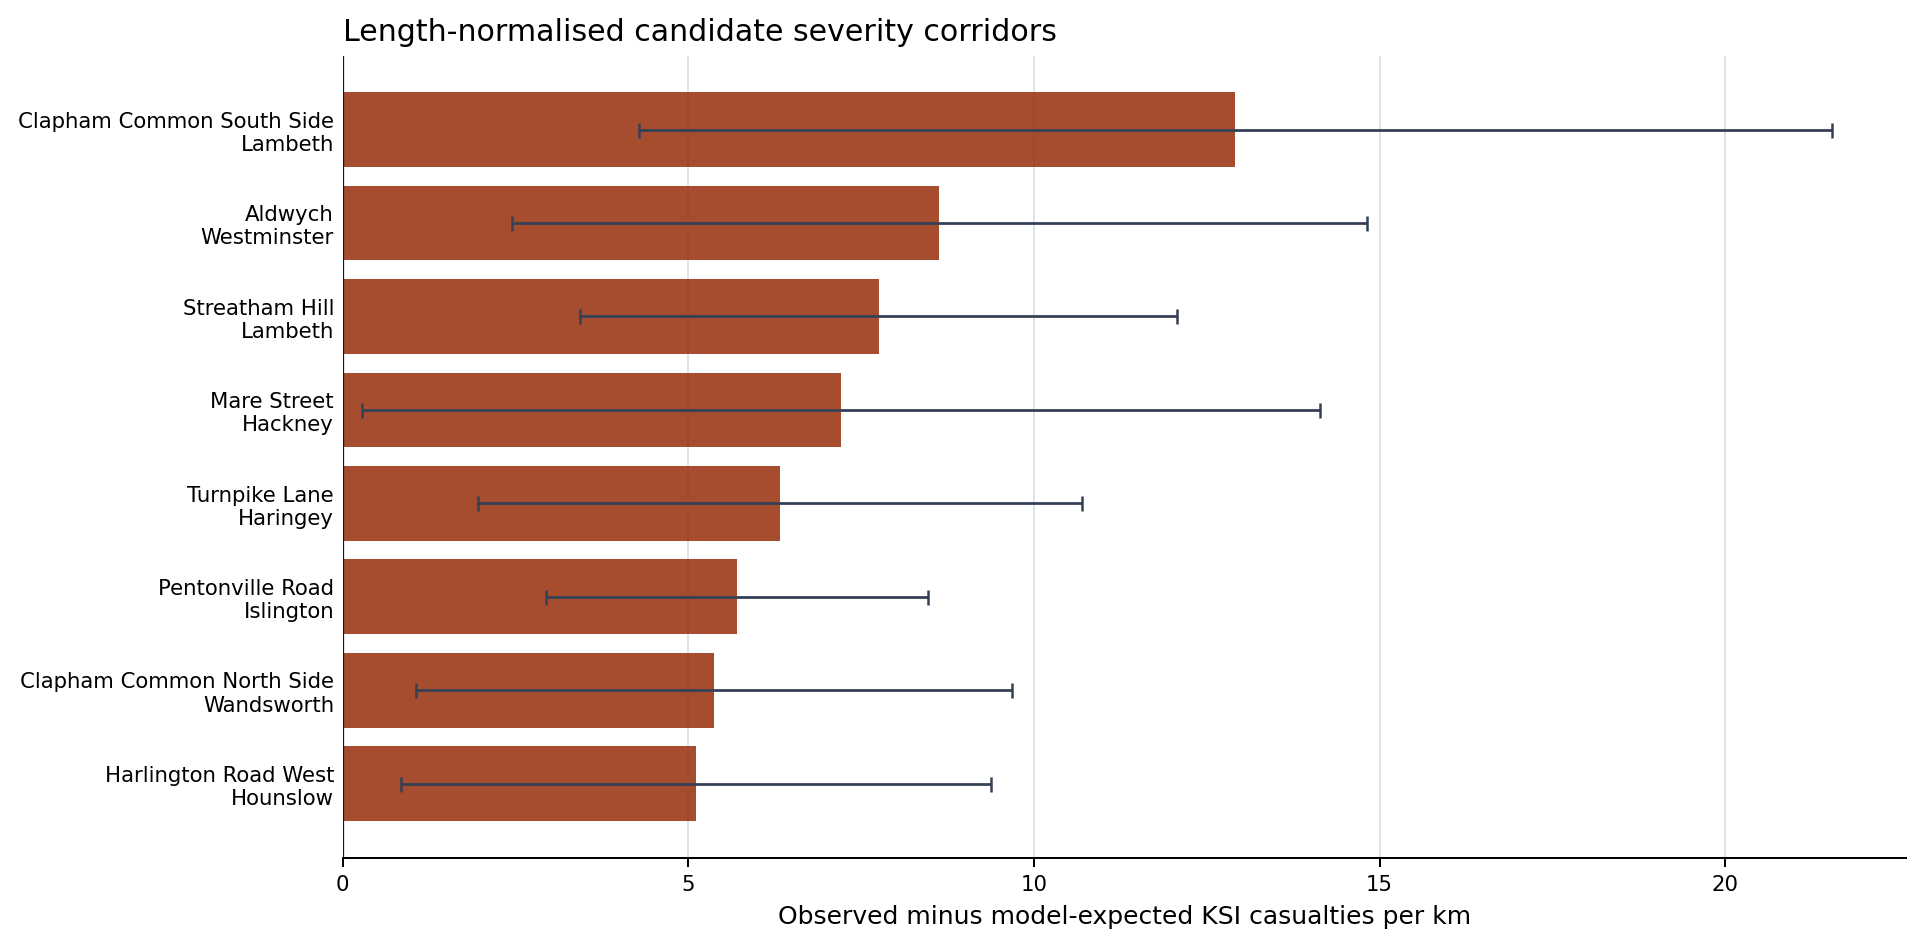

In [17]:
def corridor_axis_label(row):
    return f"{row['road_label']}\n{row['borough_name']}"

bar_rows = road_rank.sort_values("residual_per_km", ascending=True).copy()
fig, ax = plt.subplots(figsize=(10.8, 5.4))
y_labels = [corridor_axis_label(row) for _, row in bar_rows.iterrows()]
x = bar_rows["residual_per_km"].to_numpy()
xerr = np.vstack([
    np.maximum(x - bar_rows["residual_per_km_low"].to_numpy(), 0),
    np.maximum(bar_rows["residual_per_km_high"].to_numpy() - x, 0),
])
ax.barh(y_labels, x, color="#9a3412", alpha=0.88)
ax.errorbar(x, np.arange(len(bar_rows)), xerr=xerr, fmt="none", ecolor="#344054", elinewidth=1.1, capsize=3)
ax.axvline(0, color="#111827", linewidth=0.9)
ax.set_xlabel("Observed minus model-expected KSI casualties per km")
ax.set_title("Length-normalised candidate severity corridors", fontsize=12, loc="left")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#dbe3ec", linewidth=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=8.5)
ax.tick_params(axis="x", labelsize=8.5)
plt.tight_layout()
plt.show()

corridor_summary = road_rank.sort_values("residual_per_km", ascending=False).copy()
corridor_summary["expected_ksi"] = corridor_summary["expected_ksi"].round(1)
corridor_summary["residual_ksi"] = corridor_summary["residual_ksi"].round(1)
corridor_summary["corridor_length_km"] = corridor_summary["corridor_length_km"].round(2)
corridor_summary["residual_per_km"] = corridor_summary["residual_per_km"].round(2)
corridor_display = (
    corridor_summary[["road_label", "borough_name", "casualties", "ksi", "expected_ksi", "residual_ksi", "corridor_length_km", "residual_per_km"]]
    .rename(columns={
        "road_label": "Road",
        "borough_name": "Borough",
        "casualties": "Casualties",
        "ksi": "Observed KSI",
        "expected_ksi": "Expected KSI",
        "residual_ksi": "Excess KSI",
        "corridor_length_km": "Assigned km",
        "residual_per_km": "Excess KSI/km",
    })
)
display(
    corridor_display
    .style.hide(axis="index")
    .format({
        "Casualties": "{:.0f}",
        "Observed KSI": "{:.0f}",
        "Expected KSI": "{:.1f}",
        "Excess KSI": "{:.1f}",
        "Assigned km": "{:.2f}",
        "Excess KSI/km": "{:.2f}",
    })
    .set_properties(**{"text-align": "left", "font-size": "8.8pt"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "8.8pt")]},
        {"selector": "td", "props": [("padding", "3px 6px")]},
    ])
)


**Figure 9. Candidate severity corridors ranked by excess KSI per assigned kilometre.**

Figure 9 converts the residual diagnosis into named corridor candidates. Ranking by excess KSI per assigned kilometre prevents long roads from dominating only because they contain more links, but it also makes short corridors sensitive to small numbers. Corridors such as Clapham Common South Side, Aldwych, and Streatham Hill should therefore be read as audit candidates where model-adjusted severity appears high, rather than as a definitive ranking of London's most dangerous roads.


## Conclusion

[[ go back to the top ]](#Table-of-contents)

This analysis answers the research question in two steps. First, vulnerable-road-user KSI severity in Greater London is not a uniform city-wide gap: after adjustment, pedestrians, cyclists, and motorcyclists remain above car/taxi occupants, and the gap widens in specific speed and lighting contexts. Second, once casualty, collision, vehicle, temporal, traffic-flow, and neighbourhood context are controlled, residual severity remains uneven across LSOAs and selected named corridors. The strongest review candidates are therefore not simply places with many casualties, but places where observed KSI remains above model expectation and is spatially reinforced by neighbouring residuals.

The interpretation remains bounded by exposure. Borough vehicle-kilometres improve on raw counts, but they do not measure pedestrian or cycling exposure at the precise casualty location. STATS19 under-reporting, OSM road-link assignment, short corridor lengths, and the use of one year of data also limit causal or definitive safety claims. The outputs should therefore guide targeted field review and further multi-year, mode-specific exposure analysis rather than be treated as a final danger ranking.


## References

[[ go back to the top ]](#Table-of-contents)

Belin, M. Å., Tillgren, P., & Vedung, E. (2012). Vision Zero: A road safety policy innovation. *International Journal of Injury Control and Safety Promotion*, 19(2), 171-179. https://doi.org/10.1080/17457300.2011.635213

Bíl, M., Andrášik, R., & Janoška, Z. (2013). Identification of hazardous road locations of traffic accidents by means of kernel density estimation and cluster significance evaluation. *Accident Analysis & Prevention*, 55, 265-273. https://doi.org/10.1016/j.aap.2013.03.003

Department for Transport. (2025). *Road Safety Open Data*. https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

Greater London Authority. (2025). *Traffic Flows, Borough*. https://data.london.gov.uk/dataset/traffic-flows-borough/

Høye, A. K., & Hesjevoll, I. S. (2020). Traffic volume and crashes and how crash and road characteristics affect their relationship: A meta-analysis. *Accident Analysis & Prevention*, 145, 105668. https://doi.org/10.1016/j.aap.2020.105668

Ministry of Housing, Communities & Local Government. (2019). *English indices of deprivation 2019*. https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019

Musunuru, A., & Porter, R. J. (2019). Applications of measurement error correction approaches in statistical road safety modeling. *Transportation Research Record*, 2673(8), 125-135. https://doi.org/10.1177/0361198119841856

Office for National Statistics. (2022). *Lower layer Super Output Area 2011 boundaries, generalised clipped*. https://geoportal.statistics.gov.uk/

OpenStreetMap contributors. (n.d.). *OpenStreetMap road network data*. Retrieved May 4, 2026, from https://www.openstreetmap.org/

Sarkar, C., Webster, C., & Kumari, S. (2018). Street morphology and severity of road casualties. *International Journal of Sustainable Transportation*, 12(7), 510-525. https://doi.org/10.1080/15568318.2017.1402972

Xie, Z., & Yan, J. (2008). Kernel density estimation of traffic accidents in a network space. *Computers, Environment and Urban Systems*, 32(5), 396-406. https://doi.org/10.1016/j.compenvurbsys.2008.05.001
